In [15]:
import numpy as np
from numpy.typing import ArrayLike
import tensorflow as tf
import pandas as pd
import keras
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from module import time_to_float, circular_mae_two_head

# Load the small dataset to start training
x_75 = np.load("A1_data_75/images.npy")
y_75 = np.load("A1_data_75/labels.npy")

# Normalise inputs, as in task 1
x_75 = x_75.astype('float32') / 255.0

# Split into training and test set and shuffle and since the datasets are ordered, it is recommended in the assignment spec to shuffle
x_75_train, x_75_test, y_75_train, y_75_test = train_test_split(x_75, y_75, test_size = 0.10, random_state = 2029197, shuffle = True)

# Split again into training-validation sets
x_75_train, x_75_validation, y_75_train, y_75_validation = train_test_split(x_75_train, y_75_train, test_size = 0.10, random_state = 202197)

# Separate minutes and hours in dataset
y_75_train_hour = y_75_train[:,0]
y_75_train_minutes = y_75_train[:,1]

y_75_validation_hour = y_75_validation[:,0]
y_75_validation_minutes = y_75_validation[:,1]

y_75_test_hour = y_75_test[:,0]
y_75_test_minutes = y_75_test[:,1]

# Reshape for Convolutional Layers
x_75_train = x_75_train.reshape(x_75_train.shape[0], 75, 75, 1)
x_75_test = x_75_test.reshape(x_75_test.shape[0], 75, 75, 1)
x_75_validation = x_75_validation.reshape(x_75_validation.shape[0], 75, 75, 1)

# Convert the hour labels to one-hot encoding
y_75_train_hour= tf.keras.utils.to_categorical(y_75_train_hour, num_classes=12)
y_75_validation_hour = tf.keras.utils.to_categorical(y_75_validation_hour, num_classes=12)

# Set random seed for reproducibility
keras.utils.set_random_seed(2029197)


# Define circular MAE for non-standardised minutes to try either/or
def circular_mae_minutes(y_true, y_pred):
    """
    Circular MAE for minute values (0-59 scale)
    """
    y_true = tf.cast(tf.squeeze(y_true), tf.float32)
    y_pred = tf.cast(tf.squeeze(y_pred), tf.float32)

    # Calculate circular difference on 0-59 scale
    diff = tf.abs(y_true - y_pred)
    diff_wrapped = tf.minimum(diff, 60.0 - diff)

    return tf.reduce_mean(diff_wrapped)





# Make plotting function for metrics to shorten code from now on
def plot_loss_accuracy(stat_1, stat_2, model_history, type_metric):
  """
  Function to plot results of training models with correct labels and colours
  """
  colours_labels = {"hour_prediction_loss":["steelblue", "Training loss for hour (Categorical Cross-Entropy)"],
                    "val_hour_prediction_loss":["orange", "Validation loss for hour (Categorical Cross-Entropy)"],
                    "minute_prediction_loss": ["red", "Training MSE for minute"],
                    "val_minute_prediction_loss": ["green", "Validation MSE for minute"],
                    "minute_prediction_circular_mae_minutes": ["purple", "Common sense accuracy in minutes per epoch"],
                    "val_minute_prediction_circular_mae_minutes":["gold", "Common sense accuracy in minutes per epoch for validation set"]}
  plt.plot(model_history.history[stat_1], label = colours_labels[stat_1][1], color = colours_labels[stat_1][0])
  plt.plot(model_history.history[stat_2], label = colours_labels[stat_2][1], color = colours_labels[stat_2][0])
  plt.grid(True)
  plt.title(f"Training and Validation Loss for {type_metric}")
  plt.xlabel("Epochs")
  plt.legend()
  plt.show()



Here we begin with a model with 4 2d-convolutional layers, and batch normalisation after each. The dense layers in the multi-output portion also have normalization (inspired by what we learned during the regression task).

In [16]:
input_ = keras.layers.Input(shape = x_75_train.shape[1:])

# COMMON FEATURE EXTRACTION LAYERS

## Hidden layers uses Conv2D so it can learn spatial patterns from the images, code found on pg. 455 of the book

# Start with convolutional layer with kernel of size 5 x 5 as recommended on page 461 of the book
hidden1 = keras.layers.Conv2D(filters = 30, kernel_size = 5, strides = 2, padding = "same", activation="relu")(input_)
hidden1_norm = keras.layers.BatchNormalization()(hidden1)
max_pooling_deep_1 = keras.layers.MaxPooling2D(2)(hidden1_norm)
hidden2 = keras.layers.Conv2D(filters = 75, kernel_size = 3, strides = 1, padding = "same", activation="relu")(max_pooling_deep_1)
hidden2_norm = keras.layers.BatchNormalization()(hidden2)
hidden3 = keras.layers.Conv2D(filters = 150, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden2_norm)
hidden3_norm = keras.layers.BatchNormalization()(hidden3)
max_pooling_deep_2 = keras.layers.MaxPooling2D(2)(hidden3_norm)
hidden4 = keras.layers.Conv2D(filters =300, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(max_pooling_deep_2)
hidden4_norm = keras.layers.BatchNormalization()(hidden4)
max_pooling_deep_3 = keras.layers.MaxPooling2D(2)(hidden4_norm)

# Flatten output before passing to the dense layers
flattened = keras.layers.Flatten()(max_pooling_deep_3)

# HOUR RECOGNITION LAYERS
hidden_hours = keras.layers.Dense(30, activation = "relu")(flattened)
hidden_hours = keras.layers.Dense(15, activation = "relu")(hidden_hours)
hidden_hours_norm = keras.layers.LayerNormalization()(hidden_hours)
output_hours = keras.layers.Dense(12, name = "hour_prediction", activation="softmax") (hidden_hours_norm)

# MINUTE RECOGNITION LAYERS
hidden_minutes = keras.layers.Dense(30, activation= "relu")(flattened)
hidden_minutes_norm = keras.layers.LayerNormalization()(hidden_minutes)
hidden_minutes_2 = keras.layers.Dense(15, activation = "relu")(hidden_minutes_norm)
hidden_minutes_2_norm = keras.layers.LayerNormalization()(hidden_minutes_2)
output_minutes = keras.layers.Dense(1, name = "minute_prediction", activation="linear")(hidden_minutes_2_norm)

two_head_model_1 = keras.Model(inputs=input_, outputs=[output_hours, output_minutes])

two_head_model_1.compile(loss = {"hour_prediction": "categorical_crossentropy", "minute_prediction": "mse"},
                    optimizer="Adam",
                    metrics={"minute_prediction":circular_mae_minutes})

history_two_head_model_1 = two_head_model_1.fit(x_75_train,
                                            {"hour_prediction": y_75_train_hour,
                                            "minute_prediction":y_75_train_minutes},
                                            epochs=20,
                                            validation_data=(x_75_validation,
                                                            {"hour_prediction": y_75_validation_hour,
                                                            "minute_prediction": y_75_validation_minutes}))

# Save the model so we can use it even if runtime ends
two_head_model_1.save("two_head_model_1.keras")

Epoch 1/20
456/456 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - hour_prediction_loss: 2.5350 - loss: 775.0750 - minute_prediction_circular_mae_minutes: 15.0872 - minute_prediction_loss: 772.5392 - val_hour_prediction_loss: 2.5307 - val_loss: 475.6117 - val_minute_prediction_circular_mae_minutes: 14.4377 - val_minute_prediction_loss: 473.2421
Epoch 2/20
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - hour_prediction_loss: 2.4871 - loss: 334.7711 - minute_prediction_circular_mae_minutes: 15.0388 - minute_prediction_loss: 332.2839 - val_hour_prediction_loss: 2.4980 - val_loss: 288.3100 - val_minute_prediction_circular_mae_minutes: 14.4426 - val_minute_prediction_loss: 285.9274
Epoch 3/20
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - hour_prediction_loss: 2.4660 - loss: 260.1208 - minute_prediction_circular_mae_minutes: 13.1924 - minute_prediction_loss: 257.6547 - val_hour_prediction_loss: 2.4856 - val_loss: 289.7462 - val_minute_prediction_circular_mae_minutes: 13.6351 - val_minute_prediction_loss: 287.

In [ ]:
# Compute the common sense MAE for the hours
common_sense_mae_hours_mod_1 = circular_mae_two_head(two_head_model_1, x_75_test, y_75_test)

# Print the output on the minutes scale
error_in_minutes_model_1 = common_sense_mae_hours_mod_1 * 720
print("Common sense error in minutes for model 1: ", error_in_minutes_model_1)

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step
Common sense error in minutes for model 1:  30.271666666666665


Now we plot the loss/accuracy per epoch to try to notice patterns and adjust the model. However, since the scales for minutes and hours are very different, the scale of their respective losses will also end up being quite different, meaning that we should plot them separately to be able to notice whether learning is really "moving" epoch on epoch.

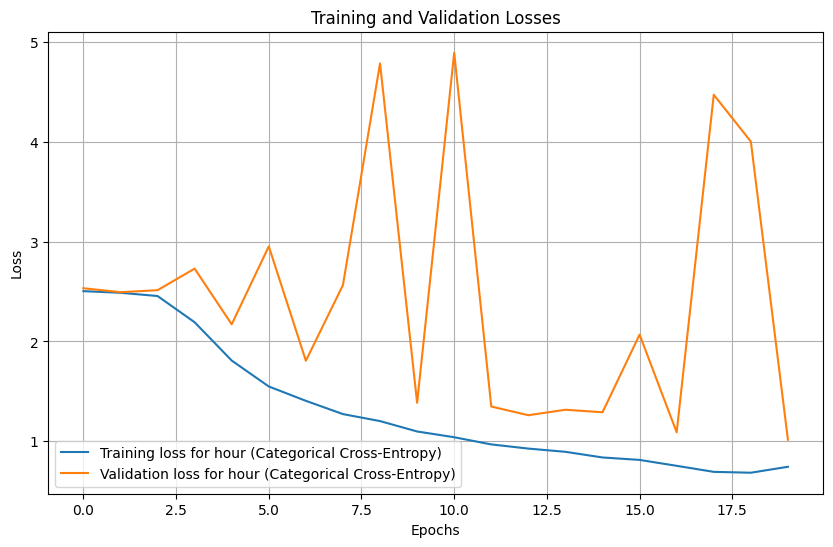

In [ ]:
# Plot the loss per epoch for hours
plt.figure(figsize = (10,6))
plt.plot(history_two_head_model_1.history["hour_prediction_loss"], label = "Training loss for hour (Categorical Cross-Entropy)")
plt.plot(history_two_head_model_1.history["val_hour_prediction_loss"], label = "Validation loss for hour (Categorical Cross-Entropy)")
plt.grid(True)
plt.title("Training and Validation Losses")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

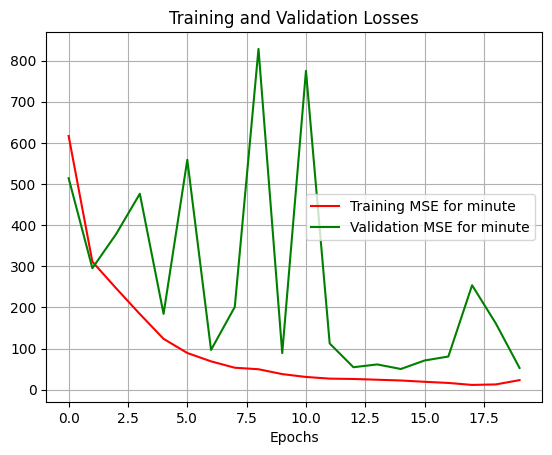

In [ ]:
# Plot the loss and accuracy per epoch for minutes
plt.plot(history_two_head_model_1.history["minute_prediction_loss"], label = "Training MSE for minute", color = "red")
plt.plot(history_two_head_model_1.history["val_minute_prediction_loss"], label = "Validation MSE for minute", color = "green")
plt.grid(True)
plt.title("Training and Validation Losses")
plt.xlabel("Epochs")
plt.legend()
plt.show()


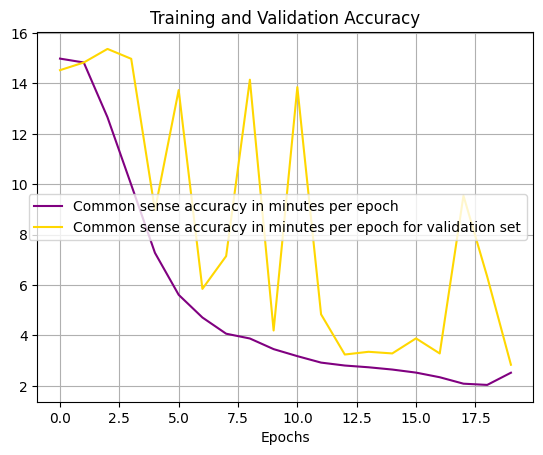

In [ ]:
# Plot the common sense accuracy per epoch for minutes
plt.plot(history_two_head_model_1.history["minute_prediction_circular_mae_minutes"], label = "Common sense accuracy in minutes per epoch", color = "purple")
plt.plot(history_two_head_model_1.history["val_minute_prediction_circular_mae_minutes"], label = "Common sense accuracy in minutes per epoch for validation set", color = "gold")
plt.grid(True)
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.legend()
plt.show()


For the next model, we see that the gradients appear a bit unstable (given that the validation loss jumps up and down for subsequent epochs). We try to alleviate this by reducing the learning rate for the optimiser. Since now the model is learning slower, we also increase the epochs.

In [ ]:
input_ = keras.layers.Input(shape = x_75_train.shape[1:])

# COMMON FEATURE EXTRACTION LAYERS

## Hidden layers uses Conv2D so it can learn spatial patterns from the images, code found on pg. 455 of the book

# Start with convolutional layer with kernel of size 5 x 5 as recommended on page 461 of the book
hidden1 = keras.layers.Conv2D(filters = 30, kernel_size = 5, strides = 2, padding = "same", activation="relu")(input_)
hidden1_norm = keras.layers.BatchNormalization()(hidden1)
max_pooling_deep_1 = keras.layers.MaxPooling2D(2)(hidden1_norm)
hidden2 = keras.layers.Conv2D(filters = 75, kernel_size = 3, strides = 1, padding = "same", activation="relu")(max_pooling_deep_1)
hidden2_norm = keras.layers.BatchNormalization()(hidden2)
hidden3 = keras.layers.Conv2D(filters = 150, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden2_norm)
hidden3_norm = keras.layers.BatchNormalization()(hidden3)
max_pooling_deep_2 = keras.layers.MaxPooling2D(2)(hidden3_norm)
hidden4 = keras.layers.Conv2D(filters =300, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(max_pooling_deep_2)
hidden4_norm = keras.layers.BatchNormalization()(hidden4)
max_pooling_deep_3 = keras.layers.MaxPooling2D(2)(hidden4_norm)

# Flatten output before passing to the dense layers
flattened = keras.layers.Flatten()(max_pooling_deep_3)

# HOUR RECOGNITION LAYERS
hidden_hours = keras.layers.Dense(30, activation = "relu")(flattened)
hidden_hours = keras.layers.Dense(15, activation = "relu")(hidden_hours)
hidden_hours_norm = keras.layers.LayerNormalization()(hidden_hours)
output_hours = keras.layers.Dense(12, name = "hour_prediction", activation="softmax") (hidden_hours_norm)

# MINUTE RECOGNITION LAYERS
hidden_minutes = keras.layers.Dense(30, activation= "relu")(flattened)
hidden_minutes_norm = keras.layers.LayerNormalization()(hidden_minutes)
hidden_minutes_2 = keras.layers.Dense(15, activation = "relu")(hidden_minutes_norm)
hidden_minutes_2_norm = keras.layers.LayerNormalization()(hidden_minutes_2)
output_minutes = keras.layers.Dense(1, name = "minute_prediction", activation="linear")(hidden_minutes_2_norm)

two_head_model_2 = keras.Model(inputs=input_, outputs=[output_hours, output_minutes])

two_head_model_2.compile(loss = {"hour_prediction": "categorical_crossentropy", "minute_prediction": "mse"},
                    optimizer=keras.optimizers.Adam(learning_rate = 0.0001),
                    metrics={"minute_prediction":circular_mae_minutes})

history_two_head_model_2 = two_head_model_2.fit(x_75_train,
                                            {"hour_prediction": y_75_train_hour,
                                            "minute_prediction":y_75_train_minutes},
                                            epochs=50,
                                            validation_data=(x_75_validation,
                                                            {"hour_prediction": y_75_validation_hour,
                                                            "minute_prediction": y_75_validation_minutes}))

# Save the model so we can use it even if runtime ends
two_head_model_2.save("two_head_model_2.keras")


Epoch 1/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - hour_prediction_loss: 2.6076 - loss: 967.8142 - minute_prediction_circular_mae_minutes: 15.0699 - minute_prediction_loss: 965.2065 - val_hour_prediction_loss: 2.6273 - val_loss: 892.5839 - val_minute_prediction_circular_mae_minutes: 14.6722 - val_minute_prediction_loss: 888.7795
Epoch 2/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - hour_prediction_loss: 2.4977 - loss: 906.3983 - minute_prediction_circular_mae_minutes: 15.0777 - minute_prediction_loss: 903.9002 - val_hour_prediction_loss: 2.4874 - val_loss: 823.4113 - val_minute_prediction_circular_mae_minutes: 14.6040 - val_minute_prediction_loss: 819.8034
Epoch 3/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - hour_prediction_loss: 2.4696 - loss: 844.7625 - minute_prediction_circular_mae_minutes: 15.0893 - minute_prediction_loss: 842.2927 - val_hour_prediction_loss: 2.4694 - val_loss: 760.7916 - val_minute_prediction_circular_mae_minutes: 14.5609 - val_minute_prediction_loss: 757.2

In [ ]:
# Compute the common sense MAE for the hours
common_sense_mae_hours_mod_2 = circular_mae_two_head(two_head_model_2, x_75_test, y_75_test)

# Print the output on the minutes scale
error_in_minutes_model_2 = common_sense_mae_hours_mod_2 * 720
print("Common sense error in minutes for model 1: ", error_in_minutes_model_2)

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
Common sense error in minutes for model 1:  26.54611111111111


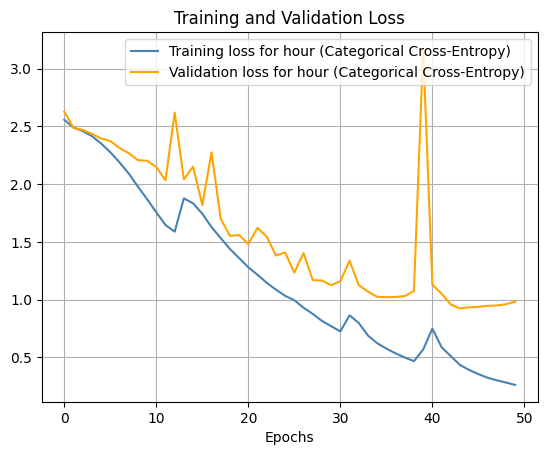

In [ ]:

# Plot hour loss per epoch
plot_loss_accuracy("hour_prediction_loss", "val_hour_prediction_loss", history_two_head_model_2, "Hours")




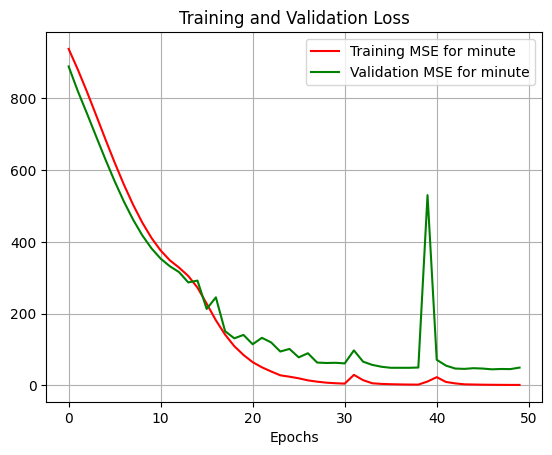

In [ ]:
# Plot minute loss per epoch
plot_loss_accuracy("minute_prediction_loss", "val_minute_prediction_loss", history_two_head_model_2, "Minutes")


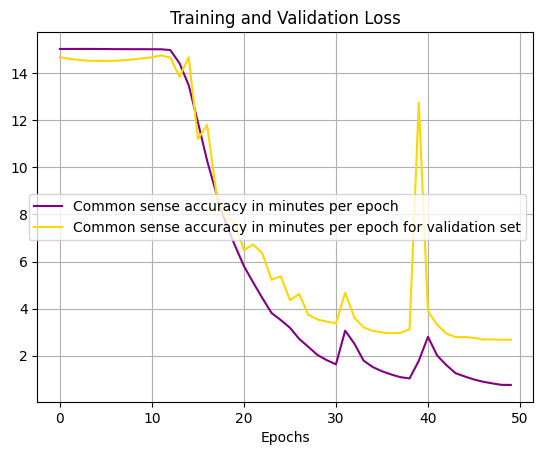

In [ ]:
# Plot common sense MAE per epoch (only for minutes)
plot_loss_accuracy("minute_prediction_circular_mae_minutes", "val_minute_prediction_circular_mae_minutes", history_two_head_model_2, "Minutes (Common Sense)")


Third Trial: We continue to observe some instability of the gradients despite the smaller learning rate. However, the common sense accuracy on the test set has significantly improved, meaning that we are on the right track.

The next step is to thus try to reduce the instability further, by trying some L2 regularisation on the dense layers to prevent the jumps. We keep the higher number of epochs, as training and validation losses do seem to keep going down even for later epochs (or at least the validation loss does not diverge from training loss and become greater).




In [ ]:
input_ = keras.layers.Input(shape = x_75_train.shape[1:])

# COMMON FEATURE EXTRACTION LAYERS

## Hidden layers uses Conv2D so it can learn spatial patterns from the images, code found on pg. 455 of the book

# Start with convolutional layer with kernel of size 5 x 5 as recommended on page 461 of the book
hidden1 = keras.layers.Conv2D(filters = 30, kernel_size = 5, strides = 2, padding = "same", activation="relu")(input_)
hidden1_norm = keras.layers.BatchNormalization()(hidden1)
max_pooling_deep_1 = keras.layers.MaxPooling2D(2)(hidden1_norm)
hidden2 = keras.layers.Conv2D(filters = 75, kernel_size = 3, strides = 1, padding = "same", activation="relu")(max_pooling_deep_1)
hidden2_norm = keras.layers.BatchNormalization()(hidden2)
hidden3 = keras.layers.Conv2D(filters = 150, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden2_norm)
hidden3_norm = keras.layers.BatchNormalization()(hidden3)
max_pooling_deep_2 = keras.layers.MaxPooling2D(2)(hidden3_norm)
hidden4 = keras.layers.Conv2D(filters =300, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(max_pooling_deep_2)
hidden4_norm = keras.layers.BatchNormalization()(hidden4)
max_pooling_deep_3 = keras.layers.MaxPooling2D(2)(hidden4_norm)

# Flatten output before passing to the dense layers
flattened = keras.layers.Flatten()(max_pooling_deep_3)

# HOUR RECOGNITION LAYERS
hidden_hours = keras.layers.Dense(60, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(flattened)
hidden_hours = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_hours)
hidden_hours_norm = keras.layers.LayerNormalization()(hidden_hours)
output_hours = keras.layers.Dense(12, name = "hour_prediction", activation="softmax", kernel_regularizer = keras.regularizers.l2(0.001)) (hidden_hours_norm)

# MINUTE RECOGNITION LAYERS
hidden_minutes = keras.layers.Dense(30, activation= "relu", kernel_regularizer = keras.regularizers.l2(0.001))(flattened)
hidden_minutes_norm = keras.layers.LayerNormalization()(hidden_minutes)
hidden_minutes_2 = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_norm)
hidden_minutes_2_norm = keras.layers.LayerNormalization()(hidden_minutes_2)
output_minutes = keras.layers.Dense(1, name = "minute_prediction", activation="linear", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_2_norm)

two_head_model_3 = keras.Model(inputs=input_, outputs=[output_hours, output_minutes])

two_head_model_3.compile(loss = {"hour_prediction": "categorical_crossentropy", "minute_prediction": "mse"},
                    optimizer=keras.optimizers.Adam(learning_rate = 0.0001),
                    metrics={"minute_prediction":circular_mae_minutes})

history_two_head_model_3 = two_head_model_3.fit(x_75_train,
                                            {"hour_prediction": y_75_train_hour,
                                            "minute_prediction":y_75_train_minutes},
                                            epochs=50,
                                            validation_data=(x_75_validation,
                                                            {"hour_prediction": y_75_validation_hour,
                                                            "minute_prediction": y_75_validation_minutes}))

# Save the model so we can use it even if runtime ends
two_head_model_3.save("two_head_model_3.keras")

Epoch 1/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - hour_prediction_loss: 2.6084 - loss: 953.6900 - minute_prediction_circular_mae_minutes: 15.0795 - minute_prediction_loss: 950.8463 - val_hour_prediction_loss: 2.6890 - val_loss: 886.9238 - val_minute_prediction_circular_mae_minutes: 14.6248 - val_minute_prediction_loss: 882.9631
Epoch 2/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - hour_prediction_loss: 2.4869 - loss: 885.1185 - minute_prediction_circular_mae_minutes: 15.0821 - minute_prediction_loss: 882.4066 - val_hour_prediction_loss: 2.4779 - val_loss: 802.9513 - val_minute_prediction_circular_mae_minutes: 14.5884 - val_minute_prediction_loss: 799.1633
Epoch 3/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - hour_prediction_loss: 2.4547 - loss: 823.7061 - minute_prediction_circular_mae_minutes: 15.0928 - minute_prediction_loss: 821.0382 - val_hour_prediction_loss: 2.4771 - val_loss: 741.5397 - val_minute_prediction_circular_mae_minutes: 14.5500 - val_minute_prediction_loss: 737.8

In [ ]:
# Compute the common sense MAE for the hours
common_sense_mae_hours_mod_3 = circular_mae_two_head(two_head_model_3, x_75_test, y_75_test)

# Print the output on the minutes scale
error_in_minutes_model_3 = common_sense_mae_hours_mod_3 * 720
print("Common sense error in minutes for model 1: ", error_in_minutes_model_3)

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Common sense error in minutes for model 1:  25.686111111111117


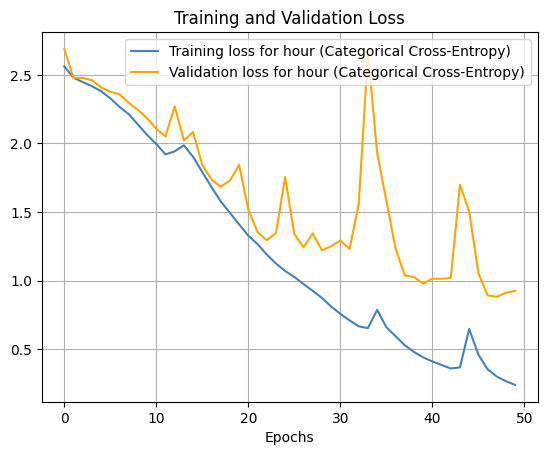

In [ ]:
# Plot hour loss per epoch
plot_loss_accuracy("hour_prediction_loss", "val_hour_prediction_loss", history_two_head_model_3, "Hours")

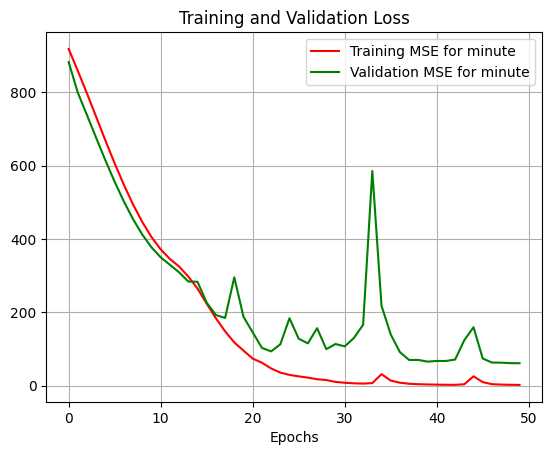

In [ ]:
# Plot minute loss per epoch
plot_loss_accuracy("minute_prediction_loss", "val_minute_prediction_loss", history_two_head_model_3, "Minutes")


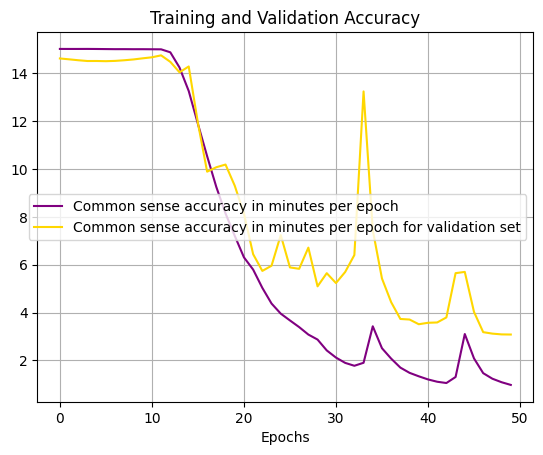

In [ ]:
# Plot common sense MAE per epoch (only for minutes)
plot_loss_accuracy("minute_prediction_circular_mae_minutes", "val_minute_prediction_circular_mae_minutes", history_two_head_model_3, "Minutes (Common Sense)")


Fourth trial: We see that regularisation did not help stabilise very much, and the common-sense accuracy has not much increased between these two runs.

Also, we notice that even with the jumps, the reduction in training loss and validation loss do not fully correspond during the later epochs, indicating some overfitting. We first try to fix this issue of overfitting by simplifying the network a little and allowing early-stopping.

In [ ]:
input_ = keras.layers.Input(shape = x_75_train.shape[1:])

# COMMON FEATURE EXTRACTION LAYERS

## Hidden layers uses Conv2D so it can learn spatial patterns from the images, code found on pg. 455 of the book

# Start with convolutional layer with kernel of size 5 x 5 as recommended on page 461 of the book
hidden1 = keras.layers.Conv2D(filters = 30, kernel_size = 5, strides = 2, padding = "same", activation="relu")(input_)
hidden1_norm = keras.layers.BatchNormalization()(hidden1)
max_pooling_deep_1 = keras.layers.MaxPooling2D(2)(hidden1_norm)
hidden2 = keras.layers.Conv2D(filters = 75, kernel_size = 3, strides = 1, padding = "same", activation="relu")(max_pooling_deep_1)
hidden2_norm = keras.layers.BatchNormalization()(hidden2)
hidden3 = keras.layers.Conv2D(filters = 150, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden2_norm)
hidden3_norm = keras.layers.BatchNormalization()(hidden3)
max_pooling_deep_2 = keras.layers.MaxPooling2D(2)(hidden3_norm)

# Flatten output before passing to the dense layers
flattened = keras.layers.Flatten()(max_pooling_deep_2)

# HOUR RECOGNITION LAYERS
hidden_hours = keras.layers.Dense(60, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(flattened)
hidden_hours = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_hours)
hidden_hours_norm = keras.layers.LayerNormalization()(hidden_hours)
output_hours = keras.layers.Dense(12, name = "hour_prediction", activation="softmax", kernel_regularizer = keras.regularizers.l2(0.001)) (hidden_hours_norm)

# MINUTE RECOGNITION LAYERS
hidden_minutes = keras.layers.Dense(30, activation= "relu", kernel_regularizer = keras.regularizers.l2(0.001))(flattened)
hidden_minutes_norm = keras.layers.LayerNormalization()(hidden_minutes)
hidden_minutes_2 = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_norm)
hidden_minutes_2_norm = keras.layers.LayerNormalization()(hidden_minutes_2)
output_minutes = keras.layers.Dense(1, name = "minute_prediction", activation="linear", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_2_norm)

two_head_model_4 = keras.Model(inputs=input_, outputs=[output_hours, output_minutes])

two_head_model_4.compile(loss = {"hour_prediction": "categorical_crossentropy", "minute_prediction": "mse"},
                    optimizer=keras.optimizers.Adam(learning_rate = 0.0001),
                    metrics={"minute_prediction":circular_mae_minutes})

history_two_head_model_4 = two_head_model_4.fit(x_75_train,
                                            {"hour_prediction": y_75_train_hour,
                                            "minute_prediction":y_75_train_minutes},
                                            epochs=50,
                                            validation_data=(x_75_validation,
                                                            {"hour_prediction": y_75_validation_hour,
                                                            "minute_prediction": y_75_validation_minutes}),
                                            callbacks = [keras.callbacks.EarlyStopping(monitor = "val_loss", patience = 10, restore_best_weights = True)]
                                                )

# Save the model so we can use it even if runtime ends
two_head_model_4.save("two_head_model_4.keras")

Epoch 1/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - hour_prediction_loss: 2.5573 - loss: 936.2640 - minute_prediction_circular_mae_minutes: 15.0757 - minute_prediction_loss: 933.4745 - val_hour_prediction_loss: 2.5472 - val_loss: 846.7254 - val_minute_prediction_circular_mae_minutes: 14.6239 - val_minute_prediction_loss: 842.8225
Epoch 2/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - hour_prediction_loss: 2.4826 - loss: 865.5573 - minute_prediction_circular_mae_minutes: 15.0861 - minute_prediction_loss: 862.8621 - val_hour_prediction_loss: 2.4841 - val_loss: 784.5115 - val_minute_prediction_circular_mae_minutes: 14.5744 - val_minute_prediction_loss: 780.7617
Epoch 3/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - hour_prediction_loss: 2.4748 - loss: 804.6522 - minute_prediction_circular_mae_minutes: 15.0959 - minute_prediction_loss: 801.9860 - val_hour_prediction_loss: 2.4780 - val_loss: 723.5502 - val_minute_prediction_circular_mae_minutes: 14.5373 - val_minute_prediction_loss: 719.

In [ ]:
# Compute the common sense MAE for the hours
common_sense_mae_hours_mod_4 = circular_mae_two_head(two_head_model_4, x_75_test, y_75_test)

# Print the output on the minutes scale
error_in_minutes_model_4 = common_sense_mae_hours_mod_4 * 720
print("Common sense error in minutes for model 1: ", error_in_minutes_model_4)

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
Common sense error in minutes for model 1:  48.06666666666667


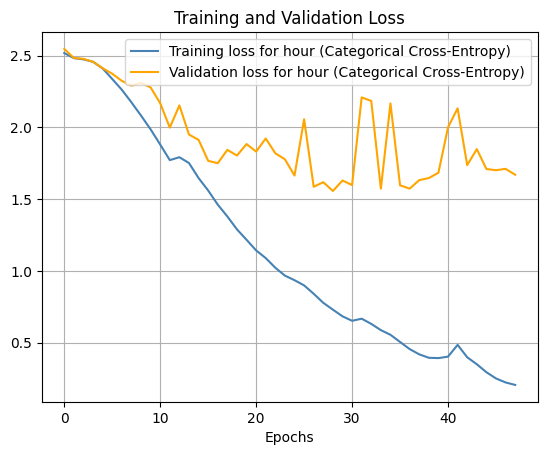

In [ ]:
# Plot hour loss per epoch
plot_loss_accuracy("hour_prediction_loss", "val_hour_prediction_loss", history_two_head_model_4, "Hours")

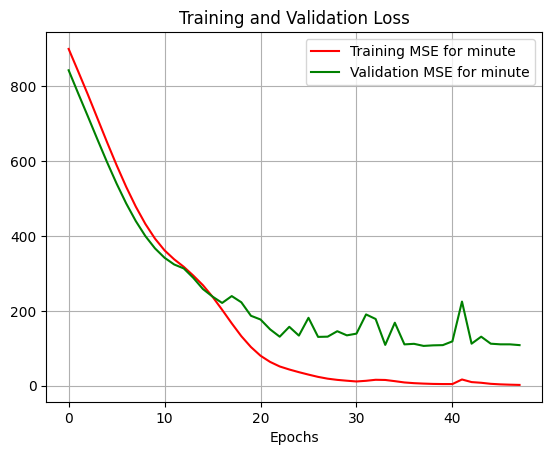

In [ ]:
# Plot minute loss per epoch
plot_loss_accuracy("minute_prediction_loss", "val_minute_prediction_loss", history_two_head_model_4, "Minutes")


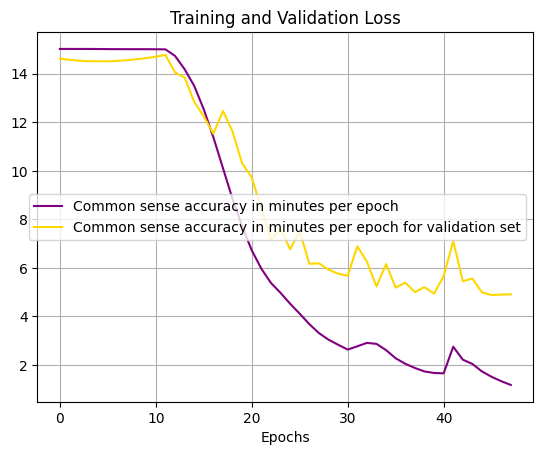

In [ ]:
# Plot common sense MAE per epoch (only for minutes)
plot_loss_accuracy("minute_prediction_circular_mae_minutes", "val_minute_prediction_circular_mae_minutes", history_two_head_model_4, "Minutes (Common Sense)")


Fifth trial: Unfortunately we see that the simplified architecture actually causes a reduction in accuracy, so we restore the final convolutional layer and try to rectify the issue of instability using dropout layers instead. We do however keep the early stopping condition.

In [ ]:
input_ = keras.layers.Input(shape = x_75_train.shape[1:])

# COMMON FEATURE EXTRACTION LAYERS

## Hidden layers uses Conv2D so it can learn spatial patterns from the images, code found on pg. 455 of the book

# Start with convolutional layer with kernel of size 5 x 5 as recommended on page 461 of the book
hidden1 = keras.layers.Conv2D(filters = 30, kernel_size = 5, strides = 2, padding = "same", activation="relu")(input_)
hidden1_norm = keras.layers.BatchNormalization()(hidden1)
max_pooling_deep_1 = keras.layers.MaxPooling2D(2)(hidden1_norm)
hidden2 = keras.layers.Conv2D(filters = 75, kernel_size = 3, strides = 1, padding = "same", activation="relu")(max_pooling_deep_1)
hidden2_norm = keras.layers.BatchNormalization()(hidden2)
hidden3 = keras.layers.Conv2D(filters = 150, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden2_norm)
hidden3_norm = keras.layers.BatchNormalization()(hidden3)
max_pooling_deep_2 = keras.layers.MaxPooling2D(2)(hidden3_norm)
hidden4 = keras.layers.Conv2D(filters =300, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(max_pooling_deep_2)
hidden4_norm = keras.layers.BatchNormalization()(hidden4)
max_pooling_deep_3 = keras.layers.MaxPooling2D(2)(hidden4_norm)

# Flatten output before passing to the dense layers
flattened = keras.layers.Flatten()(max_pooling_deep_3)
flattened = keras.layers.Dropout(0.5)(flattened)

# HOUR RECOGNITION LAYERS
hidden_hours = keras.layers.Dense(60, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(flattened)
hidden_hours = keras.layers.Dropout(0.3)(hidden_hours)
hidden_hours = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_hours)
hidden_hours = keras.layers.Dropout(0.3)(hidden_hours)
hidden_hours_norm = keras.layers.LayerNormalization()(hidden_hours)
output_hours = keras.layers.Dense(12, name = "hour_prediction", activation="softmax", kernel_regularizer = keras.regularizers.l2(0.001)) (hidden_hours_norm)

# MINUTE RECOGNITION LAYERS
hidden_minutes = keras.layers.Dense(30, activation= "relu", kernel_regularizer = keras.regularizers.l2(0.001))(flattened)
hidden_minutes= keras.layers.Dropout(0.3)(hidden_minutes)
hidden_minutes = keras.layers.LayerNormalization()(hidden_minutes)
hidden_minutes = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes)
hidden_minutes= keras.layers.Dropout(0.2)(hidden_minutes)
hidden_minutes = keras.layers.LayerNormalization()(hidden_minutes)
output_minutes = keras.layers.Dense(1, name = "minute_prediction", activation="linear", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes)

two_head_model_5 = keras.Model(inputs=input_, outputs=[output_hours, output_minutes])

two_head_model_5.compile(loss = {"hour_prediction": "categorical_crossentropy", "minute_prediction": "mse"},
                    optimizer=keras.optimizers.Adam(learning_rate = 0.0001),
                    metrics={"minute_prediction":circular_mae_minutes})

history_two_head_model_5 = two_head_model_5.fit(x_75_train,
                                            {"hour_prediction": y_75_train_hour,
                                            "minute_prediction":y_75_train_minutes},
                                            epochs=50,
                                            validation_data=(x_75_validation,
                                                            {"hour_prediction": y_75_validation_hour,
                                                            "minute_prediction": y_75_validation_minutes}),
                                            callbacks = [keras.callbacks.EarlyStopping(monitor = "val_loss", patience = 10, restore_best_weights = True)])

# Save the model so we can use it even if runtime ends
two_head_model_5.save("two_head_model_5.keras")

Epoch 1/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - hour_prediction_loss: 2.7975 - loss: 1048.7305 - minute_prediction_circular_mae_minutes: 15.0499 - minute_prediction_loss: 1045.6989 - val_hour_prediction_loss: 2.5349 - val_loss: 901.8750 - val_minute_prediction_circular_mae_minutes: 14.6758 - val_minute_prediction_loss: 897.8987
Epoch 2/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - hour_prediction_loss: 2.6438 - loss: 973.8177 - minute_prediction_circular_mae_minutes: 15.0726 - minute_prediction_loss: 970.9434 - val_hour_prediction_loss: 2.4995 - val_loss: 837.1265 - val_minute_prediction_circular_mae_minutes: 14.6160 - val_minute_prediction_loss: 833.2623
Epoch 3/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - hour_prediction_loss: 2.6069 - loss: 913.5636 - minute_prediction_circular_mae_minutes: 15.0706 - minute_prediction_loss: 910.7316 - val_hour_prediction_loss: 2.4913 - val_loss: 773.1448 - val_minute_prediction_circular_mae_minutes: 14.5676 - val_minute_prediction_loss: 76

In [ ]:
# Compute the common sense MAE for the hours
common_sense_mae_hours_mod_5 = circular_mae_two_head(two_head_model_5, x_75_test, y_75_test)

# Print the output on the minutes scale
error_in_minutes_model_5 = common_sense_mae_hours_mod_5 * 720
print("Common sense error in minutes for model 1: ", error_in_minutes_model_5)

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
Common sense error in minutes for model 1:  62.700555555555546


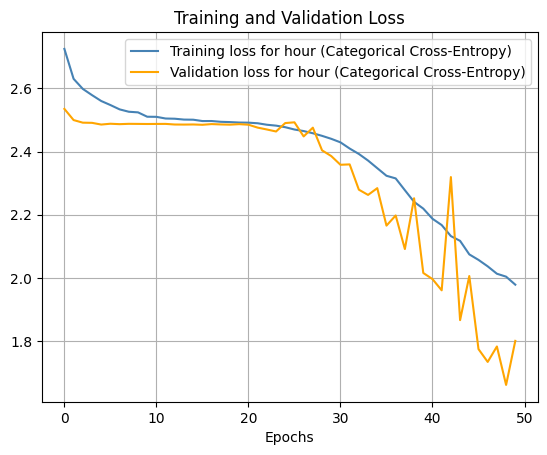

In [ ]:
# Plot hour loss per epoch
plot_loss_accuracy("hour_prediction_loss", "val_hour_prediction_loss", history_two_head_model_5, "Hours")

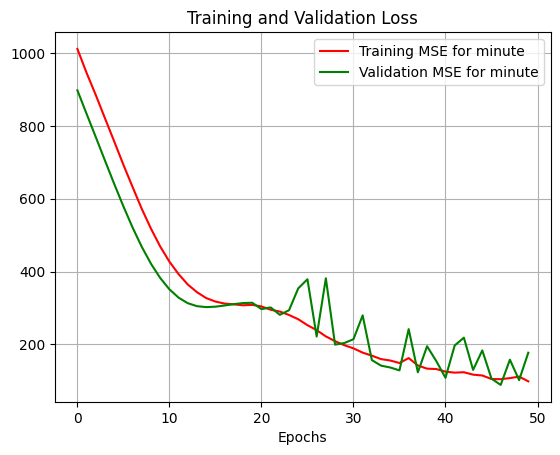

In [ ]:
# Plot minute loss per epoch
plot_loss_accuracy("minute_prediction_loss", "val_minute_prediction_loss", history_two_head_model_5, "Minutes")

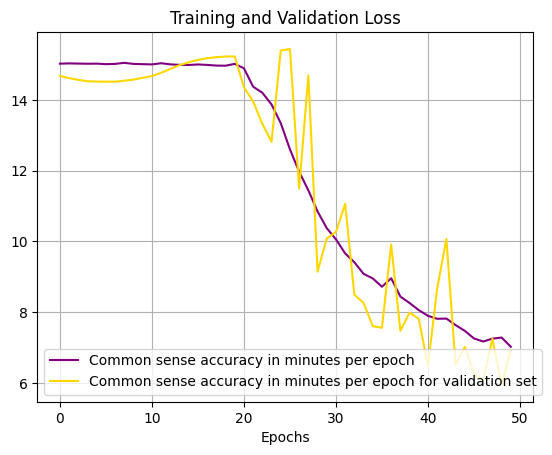

In [ ]:
# Plot common sense MAE per epoch (only for minutes)
plot_loss_accuracy("minute_prediction_circular_mae_minutes", "val_minute_prediction_circular_mae_minutes", history_two_head_model_5, "Minutes (Common Sense)")


Sixth trial: Now, while the discrepancy between validation and training set seems to be fixed, the overall prediction on the test set is worse than before. Perhaps the dropout *combined with* regularisation causes too much information loss. We try reducing the regularisation.

Moreover, given that for our task higher error for the hours leads to much worse predictions than higher error for minutes, we also try rebalancing the loss so that it prioritises hour predictions more than minutes (70-30).

In [ ]:
input_ = keras.layers.Input(shape = x_75_train.shape[1:])

# COMMON FEATURE EXTRACTION LAYERS

## Hidden layers uses Conv2D so it can learn spatial patterns from the images, code found on pg. 455 of the book

# Start with convolutional layer with kernel of size 5 x 5 as recommended on page 461 of the book
hidden1 = keras.layers.Conv2D(filters = 30, kernel_size = 5, strides = 2, padding = "same", activation="relu")(input_)
hidden1_norm = keras.layers.BatchNormalization()(hidden1)
max_pooling_deep_1 = keras.layers.MaxPooling2D(2)(hidden1_norm)
hidden2 = keras.layers.Conv2D(filters = 75, kernel_size = 3, strides = 1, padding = "same", activation="relu")(max_pooling_deep_1)
hidden2_norm = keras.layers.BatchNormalization()(hidden2)
hidden3 = keras.layers.Conv2D(filters = 150, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden2_norm)
hidden3_norm = keras.layers.BatchNormalization()(hidden3)
max_pooling_deep_2 = keras.layers.MaxPooling2D(2)(hidden3_norm)
hidden4 = keras.layers.Conv2D(filters =300, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(max_pooling_deep_2)
hidden4_norm = keras.layers.BatchNormalization()(hidden4)
max_pooling_deep_3 = keras.layers.MaxPooling2D(2)(hidden4_norm)

# Flatten output before passing to the dense layers
flattened = keras.layers.Flatten()(max_pooling_deep_3)
flattened = keras.layers.Dropout(0.5)(flattened)

# HOUR RECOGNITION LAYERS
hidden_hours = keras.layers.Dense(60, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.0001))(flattened)
hidden_hours = keras.layers.Dropout(0.3)(hidden_hours)
hidden_hours = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.0001))(hidden_hours)
hidden_hours = keras.layers.Dropout(0.3)(hidden_hours)
hidden_hours_norm = keras.layers.LayerNormalization()(hidden_hours)
output_hours = keras.layers.Dense(12, name = "hour_prediction", activation="softmax", kernel_regularizer = keras.regularizers.l2(0.001)) (hidden_hours_norm)

# MINUTE RECOGNITION LAYERS
hidden_minutes = keras.layers.Dense(30, activation= "relu", kernel_regularizer = keras.regularizers.l2(0.0001))(flattened)
hidden_minutes= keras.layers.Dropout(0.3)(hidden_minutes)
hidden_minutes = keras.layers.LayerNormalization()(hidden_minutes)
hidden_minutes = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.0001))(hidden_minutes)
hidden_minutes= keras.layers.Dropout(0.2)(hidden_minutes)
hidden_minutes = keras.layers.LayerNormalization()(hidden_minutes)
output_minutes = keras.layers.Dense(1, name = "minute_prediction", activation="linear", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes)

two_head_model_6 = keras.Model(inputs=input_, outputs=[output_hours, output_minutes])

two_head_model_6.compile(loss = {"hour_prediction": "categorical_crossentropy", "minute_prediction": "mse"},
                    optimizer=keras.optimizers.Adam(learning_rate = 0.0001),
                    loss_weights = {"hour_prediction": 0.7, "minute_prediction": 0.3},
                    metrics={"minute_prediction":circular_mae_minutes})

history_two_head_model_6 = two_head_model_6.fit(x_75_train,
                                            {"hour_prediction": y_75_train_hour,
                                            "minute_prediction":y_75_train_minutes},
                                            epochs=50,
                                            validation_data=(x_75_validation,
                                                            {"hour_prediction": y_75_validation_hour,
                                                            "minute_prediction": y_75_validation_minutes}),
                                            callbacks = [keras.callbacks.EarlyStopping(monitor = "val_loss", patience = 10, restore_best_weights = True)])

# Save the model so we can use it even if runtime ends
two_head_model_6.save("two_head_model_6.keras")

Epoch 1/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - hour_prediction_loss: 2.8070 - loss: 307.0596 - minute_prediction_circular_mae_minutes: 15.0823 - minute_prediction_loss: 1016.8579 - val_hour_prediction_loss: 2.5649 - val_loss: 254.9897 - val_minute_prediction_circular_mae_minutes: 14.6235 - val_minute_prediction_loss: 842.7001
Epoch 2/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - hour_prediction_loss: 2.6289 - loss: 279.1560 - minute_prediction_circular_mae_minutes: 15.0639 - minute_prediction_loss: 924.2616 - val_hour_prediction_loss: 2.5282 - val_loss: 235.5436 - val_minute_prediction_circular_mae_minutes: 14.5721 - val_minute_prediction_loss: 778.0555
Epoch 3/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - hour_prediction_loss: 2.6042 - loss: 259.4894 - minute_prediction_circular_mae_minutes: 15.0932 - minute_prediction_loss: 858.7636 - val_hour_prediction_loss: 2.5103 - val_loss: 216.8515 - val_minute_prediction_circular_mae_minutes: 14.5342 - val_minute_prediction_loss: 715.

In [ ]:
# Compute the common sense MAE for the hours
common_sense_mae_hours_mod_6 = circular_mae_two_head(two_head_model_6, x_75_test, y_75_test)

# Print the output on the minutes scale
error_in_minutes_model_6 = common_sense_mae_hours_mod_6 * 720
print("Common sense error in minutes for model 1: ", error_in_minutes_model_6)

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step
Common sense error in minutes for model 1:  55.99777777777778


In [ ]:
# Save the model so we can use it even if runtime ends
two_head_model_6.save("two_head_model_6.keras")


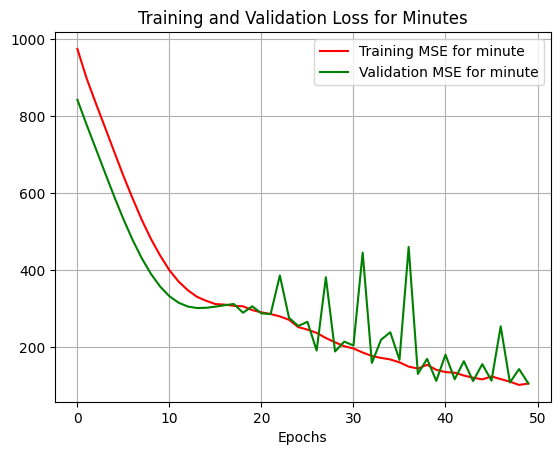

In [ ]:
# Plot minute loss per epoch
plot_loss_accuracy("minute_prediction_loss", "val_minute_prediction_loss", history_two_head_model_6, "Minutes")

Seventh Trial: The above didn't work -- it results in a worse test set common sense accuracy. Let's revert to model 4 which had the best accuracy but this time, inspired by the contents of Lecture 7, we try to achieve stability of the gradients by implementing a Residual Network architecture. This prevents shattered gradients by introducing residual connections to our network, which allow some layers to be skipped in case the gradient behaves erratically. Thus, the information passing through layers is more "gradual" allowing for the subsequent gradients to be smoother, and overall training to make more conservative steps.

In [ ]:
input_ = keras.layers.Input(shape = x_75_train.shape[1:])

# COMMON FEATURE EXTRACTION LAYERS

## Hidden layers uses Conv2D so it can learn spatial patterns from the images, code found on pg. 455 of the book

# Start with convolutional layer with kernel of size 5 x 5 as recommended on page 461 of the book
hidden1 = keras.layers.Conv2D(filters = 30, kernel_size = 5, strides = 2, padding = "same", activation="relu")(input_)
hidden1_norm = keras.layers.BatchNormalization()(hidden1)
max_pooling_deep_1 = keras.layers.MaxPooling2D(2)(hidden1_norm)
hidden2 = keras.layers.Conv2D(filters = 75, kernel_size = 3, strides = 1, padding = "same", activation="relu")(max_pooling_deep_1)
hidden2_norm = keras.layers.BatchNormalization()(hidden2)
hidden3 = keras.layers.Conv2D(filters = 150, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden2_norm)
hidden3_norm = keras.layers.BatchNormalization()(hidden3)

# We add a skip layer here in order to feed the outputs through this layer during backpropagation as well

# In order for that to work first the dimensions of hidden2_norm and hidden3_norm need to be the same so we apply the transformation:
hidden2_resized = keras.layers.Conv2D(150, kernel_size=1, strides=1, padding="same")(hidden2_norm)
skip = keras.layers.Add()([hidden2_resized, hidden3_norm])
max_pooling_deep_2 = keras.layers.MaxPooling2D(2)(skip)

# Flatten output before passing to the dense layers
flattened = keras.layers.Flatten()(max_pooling_deep_2)

# HOUR RECOGNITION LAYERS
hidden_hours = keras.layers.Dense(60, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(flattened)
hidden_hours = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_hours)
hidden_hours_norm = keras.layers.LayerNormalization()(hidden_hours)
output_hours = keras.layers.Dense(12, name = "hour_prediction", activation="softmax", kernel_regularizer = keras.regularizers.l2(0.001)) (hidden_hours_norm)

# MINUTE RECOGNITION LAYERS
hidden_minutes = keras.layers.Dense(30, activation= "relu", kernel_regularizer = keras.regularizers.l2(0.001))(flattened)
hidden_minutes_norm = keras.layers.LayerNormalization()(hidden_minutes)
hidden_minutes_2 = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_norm)
hidden_minutes_2_norm = keras.layers.LayerNormalization()(hidden_minutes_2)
output_minutes = keras.layers.Dense(1, name = "minute_prediction", activation="linear", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_2_norm)

two_head_model_7 = keras.Model(inputs=input_, outputs=[output_hours, output_minutes])

two_head_model_7.compile(loss = {"hour_prediction": "categorical_crossentropy", "minute_prediction": "mse"},
                    optimizer=keras.optimizers.Adam(learning_rate = 0.0001),
                    metrics={"minute_prediction":circular_mae_minutes})

history_two_head_model_7 = two_head_model_7.fit(x_75_train,
                                            {"hour_prediction": y_75_train_hour,
                                            "minute_prediction":y_75_train_minutes},
                                            epochs=50,
                                            validation_data=(x_75_validation,
                                                            {"hour_prediction": y_75_validation_hour,
                                                            "minute_prediction": y_75_validation_minutes}),
                                            callbacks = [keras.callbacks.EarlyStopping(monitor = "val_loss", patience = 10, restore_best_weights = True)]
                                                )

# Save the model so we can use it even if runtime ends
two_head_model_7.save("two_head_model_7.keras")

Epoch 1/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - hour_prediction_loss: 2.5821 - loss: 896.1749 - minute_prediction_circular_mae_minutes: 15.0860 - minute_prediction_loss: 893.3591 - val_hour_prediction_loss: 2.5211 - val_loss: 803.7678 - val_minute_prediction_circular_mae_minutes: 14.5887 - val_minute_prediction_loss: 799.9323
Epoch 2/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - hour_prediction_loss: 2.4756 - loss: 822.9987 - minute_prediction_circular_mae_minutes: 15.0930 - minute_prediction_loss: 820.3104 - val_hour_prediction_loss: 2.4820 - val_loss: 743.0361 - val_minute_prediction_circular_mae_minutes: 14.5509 - val_minute_prediction_loss: 739.3434
Epoch 3/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - hour_prediction_loss: 2.4511 - loss: 761.3802 - minute_prediction_circular_mae_minutes: 15.1030 - minute_prediction_loss: 758.7360 - val_hour_prediction_loss: 2.4564 - val_loss: 682.1193 - val_minute_prediction_circular_mae_minutes: 14.5181 - val_minute_prediction_loss: 678.5

In [ ]:
# Compute the common sense MAE for the hours
common_sense_mae_hours_mod_7 = circular_mae_two_head(two_head_model_7, x_75_test, y_75_test)

# Print the output on the minutes scale
error_in_minutes_model_7 = common_sense_mae_hours_mod_7 * 720
print("Common sense error in minutes for model 7: ", error_in_minutes_model_7)

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step
Common sense error in minutes for model 7:  106.44055555555555


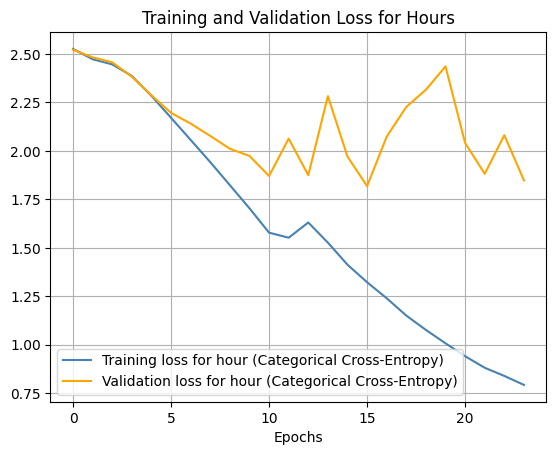

In [ ]:
# Plot hour loss per epoch
plot_loss_accuracy("hour_prediction_loss", "val_hour_prediction_loss", history_two_head_model_7, "Hours")

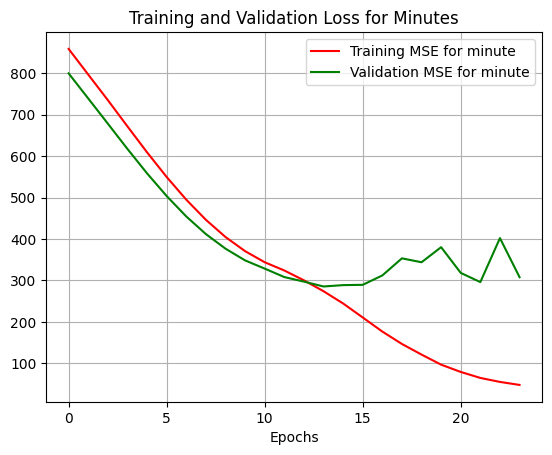

In [ ]:
# Plot hour loss per epoch
plot_loss_accuracy("minute_prediction_loss", "val_minute_prediction_loss", history_two_head_model_7, "Minutes")

Eighth Trial: The skip layer made the common sense accuracy really low, even though there was more stability in the first few epochs before the training halted. As discussed in Lecture 8, it is important to add Batch Normalization when implementing Residual Networks, so we add batch normalization after the skip layer to see if this improves performance.

Moreover, we reduce the regularisation a bit to try to tease out more signal from noise.

In [ ]:
input_ = keras.layers.Input(shape = x_75_train.shape[1:])

# COMMON FEATURE EXTRACTION LAYERS

## Hidden layers uses Conv2D so it can learn spatial patterns from the images, code found on pg. 455 of the book

# Start with convolutional layer with kernel of size 5 x 5 as recommended on page 461 of the book
hidden1 = keras.layers.Conv2D(filters = 30, kernel_size = 5, strides = 2, padding = "same", activation="relu")(input_)
hidden1_norm = keras.layers.BatchNormalization()(hidden1)
max_pooling_deep_1 = keras.layers.MaxPooling2D(2)(hidden1_norm)
hidden2 = keras.layers.Conv2D(filters = 75, kernel_size = 3, strides = 1, padding = "same", activation="relu")(max_pooling_deep_1)
hidden2_norm = keras.layers.BatchNormalization()(hidden2)
hidden3 = keras.layers.Conv2D(filters = 150, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden2_norm)
hidden3_norm = keras.layers.BatchNormalization()(hidden3)

# We add a skip layer here in order to feed the outputs through this layer during backpropagation as well

# In order for that to work first the dimensions of hidden2_norm and hidden3_norm need to be the same so we apply the transformation:
hidden2_resized = keras.layers.Conv2D(150, kernel_size=1, strides=1, padding="same")(hidden2_norm)
skip = keras.layers.Add()([hidden2_resized, hidden3_norm])
skip_norm = keras.layers.BatchNormalization()(skip)
skip_act = keras.layers.Activation("relu")(skip_norm) # Add activation also after the skip layer
max_pooling_deep_2 = keras.layers.MaxPooling2D(2)(skip_act)

# Flatten output before passing to the dense layers
flattened = keras.layers.Flatten()(max_pooling_deep_2)

# HOUR RECOGNITION LAYERS
hidden_hours = keras.layers.Dense(60, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.0001))(flattened)
hidden_hours = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.0001))(hidden_hours)
hidden_hours_norm = keras.layers.LayerNormalization()(hidden_hours)
output_hours = keras.layers.Dense(12, name = "hour_prediction", activation="softmax", kernel_regularizer = keras.regularizers.l2(0.001)) (hidden_hours_norm)

# MINUTE RECOGNITION LAYERS
hidden_minutes = keras.layers.Dense(30, activation= "relu", kernel_regularizer = keras.regularizers.l2(0.001))(flattened)
hidden_minutes_norm = keras.layers.LayerNormalization()(hidden_minutes)
hidden_minutes_2 = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_norm)
hidden_minutes_2_norm = keras.layers.LayerNormalization()(hidden_minutes_2)
output_minutes = keras.layers.Dense(1, name = "minute_prediction", activation="linear", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_2_norm)

two_head_model_8 = keras.Model(inputs=input_, outputs=[output_hours, output_minutes])

two_head_model_8.compile(loss = {"hour_prediction": "categorical_crossentropy", "minute_prediction": "mse"},
                    optimizer=keras.optimizers.Adam(learning_rate = 0.0001),
                    metrics={"minute_prediction":circular_mae_minutes})

history_two_head_model_8 = two_head_model_8.fit(x_75_train,
                                            {"hour_prediction": y_75_train_hour,
                                            "minute_prediction":y_75_train_minutes},
                                            epochs=50,
                                            validation_data=(x_75_validation,
                                                            {"hour_prediction": y_75_validation_hour,
                                                            "minute_prediction": y_75_validation_minutes}),
                                            callbacks = [keras.callbacks.EarlyStopping(monitor = "val_loss", patience = 10, restore_best_weights = True)]
                                                )

# Save the model so we can use it even if runtime ends
two_head_model_8.save("two_head_model_8.keras")

Epoch 1/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - hour_prediction_loss: 2.6077 - loss: 933.8036 - minute_prediction_circular_mae_minutes: 15.0755 - minute_prediction_loss: 931.0900 - val_hour_prediction_loss: 2.5087 - val_loss: 844.1641 - val_minute_prediction_circular_mae_minutes: 14.6232 - val_minute_prediction_loss: 840.4061
Epoch 2/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - hour_prediction_loss: 2.4911 - loss: 866.6594 - minute_prediction_circular_mae_minutes: 15.0858 - minute_prediction_loss: 864.0645 - val_hour_prediction_loss: 2.4885 - val_loss: 784.5320 - val_minute_prediction_circular_mae_minutes: 14.5744 - val_minute_prediction_loss: 780.8713
Epoch 3/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - hour_prediction_loss: 2.4770 - loss: 804.4230 - minute_prediction_circular_mae_minutes: 15.0959 - minute_prediction_loss: 801.8433 - val_hour_prediction_loss: 2.4861 - val_loss: 722.8046 - val_minute_prediction_circular_mae_minutes: 14.5368 - val_minute_prediction_loss: 719.

In [ ]:
# Compute the common sense MAE for the hours
common_sense_mae_hours_mod_8 = circular_mae_two_head(two_head_model_8, x_75_test, y_75_test)

# Print the output on the minutes scale
error_in_minutes_model_8 = common_sense_mae_hours_mod_8 * 720
print("Common sense error in minutes for model 8: ", error_in_minutes_model_8)

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
Common sense error in minutes for model 8:  63.44333333333333


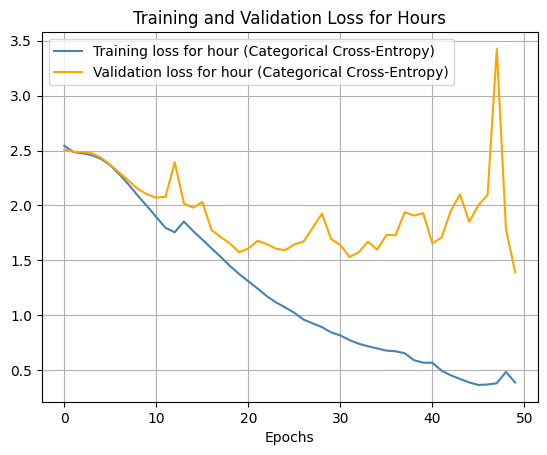

In [ ]:
# Plot hour loss per epoch
plot_loss_accuracy("hour_prediction_loss", "val_hour_prediction_loss", history_two_head_model_8, "Hours")

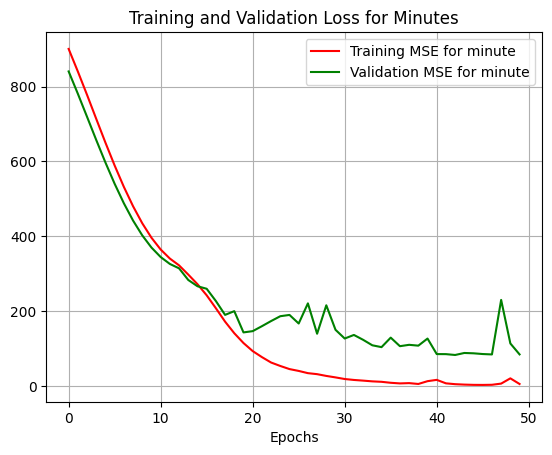

In [ ]:
# Plot hour loss per epoch
plot_loss_accuracy("minute_prediction_loss", "val_minute_prediction_loss", history_two_head_model_8, "Minutes")

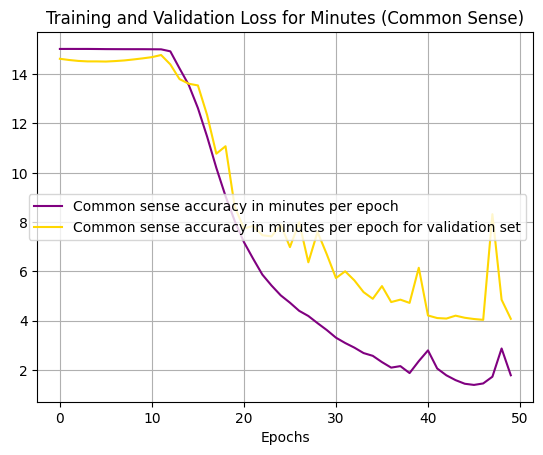

In [ ]:
# Plot common sense MAE per epoch (only for minutes)
plot_loss_accuracy("minute_prediction_circular_mae_minutes", "val_minute_prediction_circular_mae_minutes", history_two_head_model_8, "Minutes (Common Sense)")


Ninth Trial: Overfitting for hours (validation loss doesn't go along with training loss). Let's increase regularisation for it.

In [ ]:
input_ = keras.layers.Input(shape = x_75_train.shape[1:])

# COMMON FEATURE EXTRACTION LAYERS

## Hidden layers uses Conv2D so it can learn spatial patterns from the images, code found on pg. 455 of the book

# Start with convolutional layer with kernel of size 5 x 5 as recommended on page 461 of the book
hidden1 = keras.layers.Conv2D(filters = 30, kernel_size = 5, strides = 2, padding = "same", activation="relu")(input_)
hidden1_norm = keras.layers.BatchNormalization()(hidden1)
max_pooling_deep_1 = keras.layers.MaxPooling2D(2)(hidden1_norm)
hidden2 = keras.layers.Conv2D(filters = 75, kernel_size = 3, strides = 1, padding = "same", activation="relu")(max_pooling_deep_1)
hidden2_norm = keras.layers.BatchNormalization()(hidden2)
hidden3 = keras.layers.Conv2D(filters = 150, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden2_norm)
hidden3_norm = keras.layers.BatchNormalization()(hidden3)

# We add a skip layer here in order to feed the outputs through this layer during backpropagation as well

# In order for that to work first the dimensions of hidden2_norm and hidden3_norm need to be the same so we apply the transformation:
hidden2_resized = keras.layers.Conv2D(150, kernel_size=1, strides=1, padding="same")(hidden2_norm)
skip = keras.layers.Add()([hidden2_resized, hidden3_norm])
skip_norm = keras.layers.BatchNormalization()(skip)
skip_act = keras.layers.Activation("relu")(skip_norm) # Add activation also after the skip layer
max_pooling_deep_2 = keras.layers.MaxPooling2D(2)(skip_act)

# Flatten output before passing to the dense layers
flattened = keras.layers.Flatten()(max_pooling_deep_2)

# HOUR RECOGNITION LAYERS
hidden_hours = keras.layers.Dense(60, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(flattened)
hidden_hours = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_hours)
hidden_hours_norm = keras.layers.LayerNormalization()(hidden_hours)
output_hours = keras.layers.Dense(12, name = "hour_prediction", activation="softmax", kernel_regularizer = keras.regularizers.l2(0.001)) (hidden_hours_norm)

# MINUTE RECOGNITION LAYERS
hidden_minutes = keras.layers.Dense(30, activation= "relu", kernel_regularizer = keras.regularizers.l2(0.0001))(flattened)
hidden_minutes_norm = keras.layers.LayerNormalization()(hidden_minutes)
hidden_minutes_2 = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.0001))(hidden_minutes_norm)
hidden_minutes_2_norm = keras.layers.LayerNormalization()(hidden_minutes_2)
output_minutes = keras.layers.Dense(1, name = "minute_prediction", activation="linear", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_2_norm)

two_head_model_9 = keras.Model(inputs=input_, outputs=[output_hours, output_minutes])

two_head_model_9.compile(loss = {"hour_prediction": "categorical_crossentropy", "minute_prediction": "mse"},
                    optimizer=keras.optimizers.Adam(learning_rate = 0.0001),
                    metrics={"minute_prediction":circular_mae_minutes})

history_two_head_model_9 = two_head_model_9.fit(x_75_train,
                                            {"hour_prediction": y_75_train_hour,
                                            "minute_prediction":y_75_train_minutes},
                                            epochs=50,
                                            validation_data=(x_75_validation,
                                                            {"hour_prediction": y_75_validation_hour,
                                                            "minute_prediction": y_75_validation_minutes}),
                                            callbacks = [keras.callbacks.EarlyStopping(monitor = "val_loss", patience = 10, restore_best_weights = True)]
                                                )

# Save the model so we can use it even if runtime ends
two_head_model_9.save("two_head_model_9.keras")

Epoch 1/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - hour_prediction_loss: 2.5198 - loss: 919.6927 - minute_prediction_circular_mae_minutes: 15.0717 - minute_prediction_loss: 917.0177 - val_hour_prediction_loss: 2.4908 - val_loss: 833.1285 - val_minute_prediction_circular_mae_minutes: 14.6121 - val_minute_prediction_loss: 829.3727
Epoch 2/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - hour_prediction_loss: 2.4833 - loss: 854.4750 - minute_prediction_circular_mae_minutes: 15.0878 - minute_prediction_loss: 851.8652 - val_hour_prediction_loss: 2.4833 - val_loss: 771.1131 - val_minute_prediction_circular_mae_minutes: 14.5665 - val_minute_prediction_loss: 767.4693
Epoch 3/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - hour_prediction_loss: 2.4765 - loss: 790.0966 - minute_prediction_circular_mae_minutes: 15.0979 - minute_prediction_loss: 787.5157 - val_hour_prediction_loss: 2.4736 - val_loss: 708.3228 - val_minute_prediction_circular_mae_minutes: 14.5259 - val_minute_prediction_loss: 704.7

In [ ]:
# Compute the common sense MAE for the hours
common_sense_mae_hours_mod_9 = circular_mae_two_head(two_head_model_9, x_75_test, y_75_test)

# Print the output on the minutes scale
error_in_minutes_model_9 = common_sense_mae_hours_mod_9 * 720
print("Common sense error in minutes for model 9: ", error_in_minutes_model_9)

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step
Common sense error in minutes for model 9:  47.047222222222224


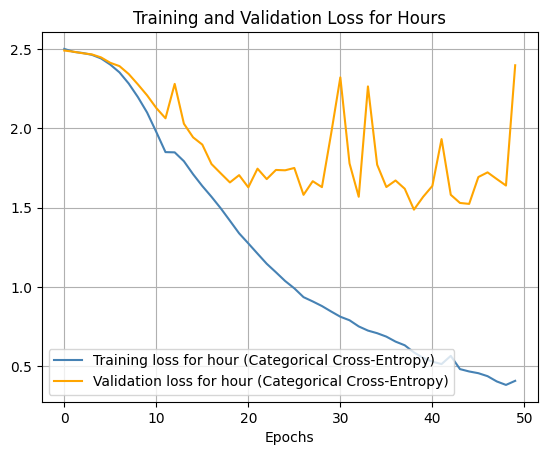

In [ ]:
# Plot hour loss per epoch
plot_loss_accuracy("hour_prediction_loss", "val_hour_prediction_loss", history_two_head_model_9, "Hours")

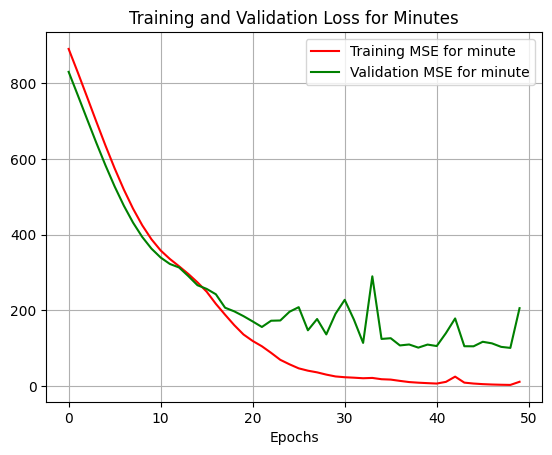

In [ ]:
# Plot hour loss per epoch
plot_loss_accuracy("minute_prediction_loss", "val_minute_prediction_loss", history_two_head_model_9, "Minutes")

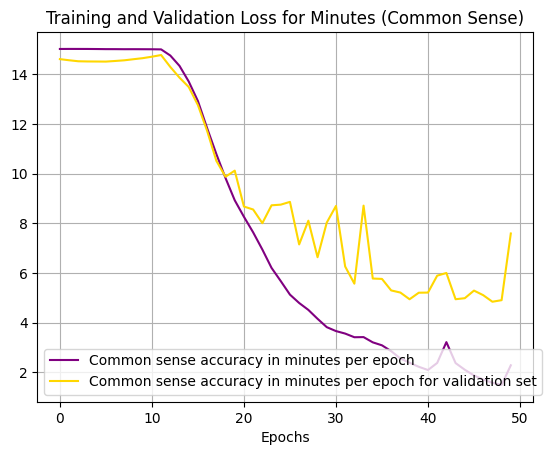

In [ ]:
# Plot common sense MAE per epoch (only for minutes)
plot_loss_accuracy("minute_prediction_circular_mae_minutes", "val_minute_prediction_circular_mae_minutes", history_two_head_model_9, "Minutes (Common Sense)")


Tenth Trial: Overfitting for hours still (validation loss doesn't go along with training loss). But there was some improvement to the accuracy. Let's increase regularisation and replace normalisation with dropout.

In [ ]:
input_ = keras.layers.Input(shape = x_75_train.shape[1:])

# COMMON FEATURE EXTRACTION LAYERS

## Hidden layers uses Conv2D so it can learn spatial patterns from the images, code found on pg. 455 of the book

# Start with convolutional layer with kernel of size 5 x 5 as recommended on page 461 of the book
hidden1 = keras.layers.Conv2D(filters = 30, kernel_size = 5, strides = 2, padding = "same", activation="relu")(input_)
hidden1_norm = keras.layers.BatchNormalization()(hidden1)
max_pooling_deep_1 = keras.layers.MaxPooling2D(2)(hidden1_norm)
hidden2 = keras.layers.Conv2D(filters = 75, kernel_size = 3, strides = 1, padding = "same", activation="relu")(max_pooling_deep_1)
hidden2_norm = keras.layers.BatchNormalization()(hidden2)
hidden3 = keras.layers.Conv2D(filters = 150, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden2_norm)
hidden3_norm = keras.layers.BatchNormalization()(hidden3)

# We add a skip layer here in order to feed the outputs through this layer during backpropagation as well

# In order for that to work first the dimensions of hidden2_norm and hidden3_norm need to be the same so we apply the transformation:
hidden2_resized = keras.layers.Conv2D(150, kernel_size=1, strides=1, padding="same")(hidden2_norm)
skip = keras.layers.Add()([hidden2_resized, hidden3_norm])
skip_norm = keras.layers.BatchNormalization()(skip)
skip_act = keras.layers.Activation("relu")(skip_norm) # Add activation also after the skip layer
max_pooling_deep_2 = keras.layers.MaxPooling2D(2)(skip_act)

# Flatten output before passing to the dense layers
flattened = keras.layers.Flatten()(max_pooling_deep_2)

# HOUR RECOGNITION LAYERS
hidden_hours = keras.layers.Dense(60, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.01))(flattened)
hidden_hours = keras.layers.Dropout(0.1)(hidden_hours)
hidden_hours = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.01))(hidden_hours)
output_hours = keras.layers.Dense(12, name = "hour_prediction", activation="softmax", kernel_regularizer = keras.regularizers.l2(0.001)) (hidden_hours)

# MINUTE RECOGNITION LAYERS
hidden_minutes = keras.layers.Dense(30, activation= "relu", kernel_regularizer = keras.regularizers.l2(0.0001))(flattened)
hidden_minutes_norm = keras.layers.LayerNormalization()(hidden_minutes)
hidden_minutes_2 = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.0001))(hidden_minutes_norm)
hidden_minutes_2_norm = keras.layers.LayerNormalization()(hidden_minutes_2)
output_minutes = keras.layers.Dense(1, name = "minute_prediction", activation="linear", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_2_norm)

two_head_model_10 = keras.Model(inputs=input_, outputs=[output_hours, output_minutes])

two_head_model_10.compile(loss = {"hour_prediction": "categorical_crossentropy", "minute_prediction": "mse"},
                    optimizer=keras.optimizers.Adam(learning_rate = 0.0001),
                    metrics={"minute_prediction":circular_mae_minutes})

history_two_head_model_10 = two_head_model_10.fit(x_75_train,
                                            {"hour_prediction": y_75_train_hour,
                                            "minute_prediction":y_75_train_minutes},
                                            epochs=50,
                                            validation_data=(x_75_validation,
                                                            {"hour_prediction": y_75_validation_hour,
                                                            "minute_prediction": y_75_validation_minutes}),
                                            callbacks = [keras.callbacks.EarlyStopping(monitor = "val_loss", patience = 10, restore_best_weights = True)]
                                                )

# Save the model so we can use it even if runtime ends
two_head_model_10.save("two_head_model_10.keras")

Epoch 1/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - hour_prediction_loss: 2.5033 - loss: 948.4829 - minute_prediction_circular_mae_minutes: 15.0706 - minute_prediction_loss: 944.7398 - val_hour_prediction_loss: 2.4850 - val_loss: 859.5121 - val_minute_prediction_circular_mae_minutes: 14.6365 - val_minute_prediction_loss: 855.1656
Epoch 2/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - hour_prediction_loss: 2.4895 - loss: 882.3379 - minute_prediction_circular_mae_minutes: 15.0828 - minute_prediction_loss: 879.2571 - val_hour_prediction_loss: 2.4850 - val_loss: 799.2449 - val_minute_prediction_circular_mae_minutes: 14.5854 - val_minute_prediction_loss: 795.3146
Epoch 3/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - hour_prediction_loss: 2.4854 - loss: 819.6668 - minute_prediction_circular_mae_minutes: 15.0936 - minute_prediction_loss: 816.8710 - val_hour_prediction_loss: 2.4750 - val_loss: 737.2637 - val_minute_prediction_circular_mae_minutes: 14.5473 - val_minute_prediction_loss: 733.5

In [ ]:
# Compute the common sense MAE for the hours
common_sense_mae_hours_mod_10 = circular_mae_two_head(two_head_model_10, x_75_test, y_75_test)

# Print the output on the minutes scale
error_in_minutes_model_10 = common_sense_mae_hours_mod_10 * 720
print("Common sense error in minutes for model 10: ", error_in_minutes_model_10)

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
Common sense error in minutes for model 10:  63.64055555555556


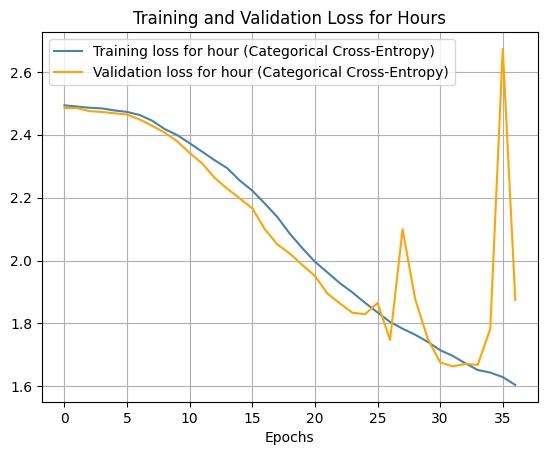

In [ ]:
# Plot hour loss per epoch
plot_loss_accuracy("hour_prediction_loss", "val_hour_prediction_loss", history_two_head_model_10, "Hours")

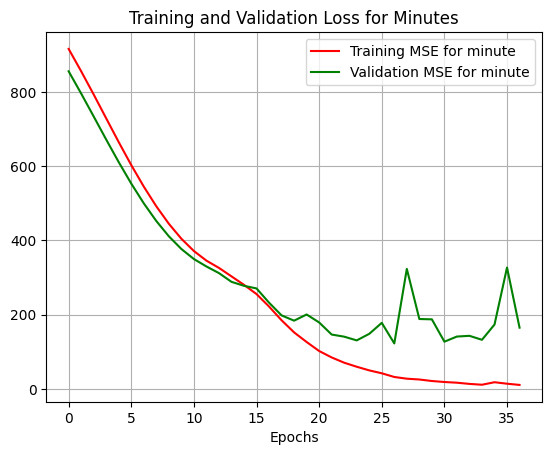

In [ ]:
# Plot hour loss per epoch
plot_loss_accuracy("minute_prediction_loss", "val_minute_prediction_loss", history_two_head_model_10, "Minutes")

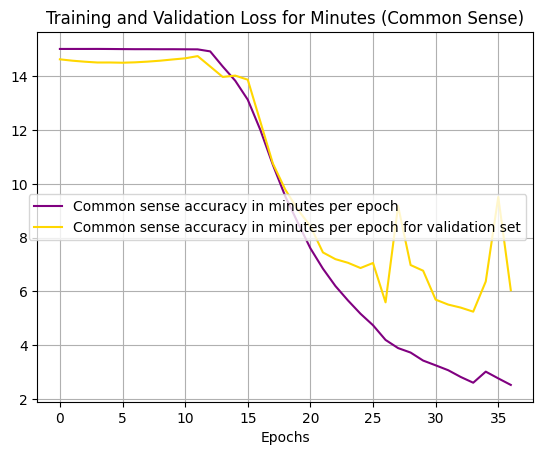

In [ ]:
# Plot common sense MAE per epoch (only for minutes)
plot_loss_accuracy("minute_prediction_circular_mae_minutes", "val_minute_prediction_circular_mae_minutes", history_two_head_model_10, "Minutes (Common Sense)")


In [ ]:
input_ = keras.layers.Input(shape = x_75_train.shape[1:])

# COMMON FEATURE EXTRACTION LAYERS

## Hidden layers uses Conv2D so it can learn spatial patterns from the images, code found on pg. 455 of the book

# Start with convolutional layer with kernel of size 5 x 5 as recommended on page 461 of the book
hidden1 = keras.layers.Conv2D(filters = 30, kernel_size = 5, strides = 2, padding = "same", activation="relu")(input_)
hidden1_norm = keras.layers.BatchNormalization()(hidden1)
max_pooling_deep_1 = keras.layers.MaxPooling2D(2)(hidden1_norm)
hidden2 = keras.layers.Conv2D(filters = 75, kernel_size = 3, strides = 1, padding = "same", activation="relu")(max_pooling_deep_1)
hidden2_norm = keras.layers.BatchNormalization()(hidden2)
hidden3 = keras.layers.Conv2D(filters = 150, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden2_norm)
hidden3_norm = keras.layers.BatchNormalization()(hidden3)

# Add one more layer for better learning
hidden4= keras.layers.Conv2D(filters = 300, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden2_norm)
hidden4_norm = keras.layers.BatchNormalization()(hidden4)



# We add a skip layer here in order to feed the outputs through this layer during backpropagation as well

# In order for that to work first the dimensions of hidden2_norm and hidden3_norm need to be the same so we apply the transformation:
hidden2_resized = keras.layers.Conv2D(150, kernel_size=1, strides=1, padding="same")(hidden2_norm)
skip = keras.layers.Add()([hidden2_resized, hidden3_norm])
skip_norm = keras.layers.BatchNormalization()(skip)
skip_act = keras.layers.Activation("relu")(skip_norm) # Add activation also after the skip layer
max_pooling_deep_2 = keras.layers.MaxPooling2D(2)(skip_act)

# Add another skip layer along with the new convolutional layer
hidden3_resized = keras.layers.Conv2D(300, kernel_size=1, strides=1, padding="same")(hidden3_norm)
skip_2 = keras.layers.Add()([hidden3_resized, hidden4_norm])
skip_norm_2 = keras.layers.BatchNormalization()(skip_2)
skip_act_2 = keras.layers.Activation("relu")(skip_norm_2) # Add activation also after the skip layer
max_pooling_deep_3 = keras.layers.MaxPooling2D(2)(skip_act_2)


# Flatten output before passing to the dense layers
flattened = keras.layers.Flatten()(max_pooling_deep_3)

# HOUR RECOGNITION LAYERS
hidden_hours = keras.layers.Dense(60, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(flattened)
hidden_hours = keras.layers.Dropout(0.1)(hidden_hours)
hidden_hours = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_hours)
output_hours = keras.layers.Dense(12, name = "hour_prediction", activation="softmax", kernel_regularizer = keras.regularizers.l2(0.001)) (hidden_hours)

# MINUTE RECOGNITION LAYERS
hidden_minutes = keras.layers.Dense(30, activation= "relu", kernel_regularizer = keras.regularizers.l2(0.001))(flattened)
hidden_minutes_norm = keras.layers.LayerNormalization()(hidden_minutes)
hidden_minutes_2 = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_norm)
hidden_minutes_2_norm = keras.layers.LayerNormalization()(hidden_minutes_2)
output_minutes = keras.layers.Dense(1, name = "minute_prediction", activation="linear", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_2_norm)

two_head_model_11 = keras.Model(inputs=input_, outputs=[output_hours, output_minutes])

two_head_model_11.compile(loss = {"hour_prediction": "categorical_crossentropy", "minute_prediction": "mse"},
                    optimizer=keras.optimizers.Adam(learning_rate = 0.0001),
                    metrics={"minute_prediction":circular_mae_minutes})

history_two_head_model_11 = two_head_model_11.fit(x_75_train,
                                            {"hour_prediction": y_75_train_hour,
                                            "minute_prediction":y_75_train_minutes},
                                            epochs=50,
                                            validation_data=(x_75_validation,
                                                            {"hour_prediction": y_75_validation_hour,
                                                            "minute_prediction": y_75_validation_minutes}),
                                            callbacks = [keras.callbacks.EarlyStopping(monitor = "val_loss", patience = 10, restore_best_weights = True)]
                                                )

# Save the model so we can use it even if runtime ends
two_head_model_11.save("two_head_model_11.keras")

Epoch 1/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - hour_prediction_loss: 2.5652 - loss: 912.3114 - minute_prediction_circular_mae_minutes: 15.0677 - minute_prediction_loss: 909.5201 - val_hour_prediction_loss: 2.4852 - val_loss: 824.9407 - val_minute_prediction_circular_mae_minutes: 14.6051 - val_minute_prediction_loss: 821.1314
Epoch 2/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - hour_prediction_loss: 2.4851 - loss: 846.6533 - minute_prediction_circular_mae_minutes: 15.0892 - minute_prediction_loss: 843.9719 - val_hour_prediction_loss: 2.4848 - val_loss: 765.3508 - val_minute_prediction_circular_mae_minutes: 14.5633 - val_minute_prediction_loss: 761.6408
Epoch 3/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - hour_prediction_loss: 2.4850 - loss: 784.7270 - minute_prediction_circular_mae_minutes: 15.0989 - minute_prediction_loss: 782.0644 - val_hour_prediction_loss: 2.4849 - val_loss: 704.8981 - val_minute_prediction_circular_mae_minutes: 14.5233 - val_minute_prediction_loss: 701

In [ ]:
# Compute the common sense MAE for the hours
common_sense_mae_hours_mod_11 = circular_mae_two_head(two_head_model_11, x_75_test, y_75_test)

# Print the output on the minutes scale
error_in_minutes_model_11 = common_sense_mae_hours_mod_11 * 720
print("Common sense error in minutes for model 11: ", error_in_minutes_model_11)

57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step
Common sense error in minutes for model 11:  85.30499999999999


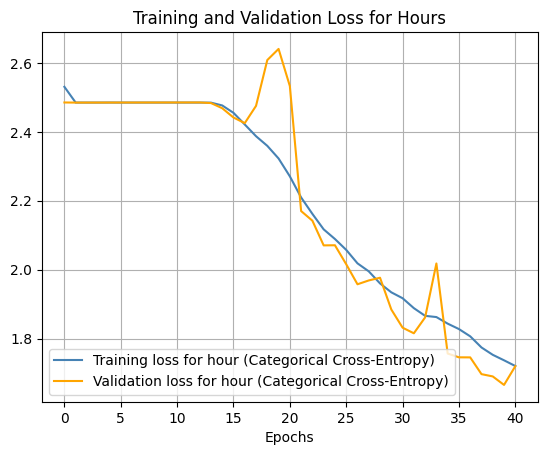

In [ ]:
# Plot hour loss per epoch
plot_loss_accuracy("hour_prediction_loss", "val_hour_prediction_loss", history_two_head_model_11, "Hours")

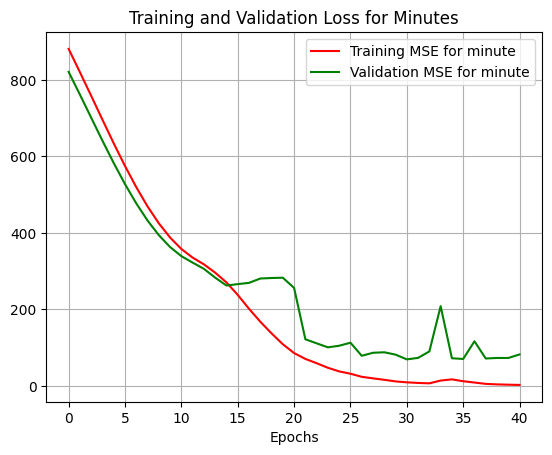

In [ ]:
# Plot hour loss per epoch
plot_loss_accuracy("minute_prediction_loss", "val_minute_prediction_loss", history_two_head_model_11, "Minutes")

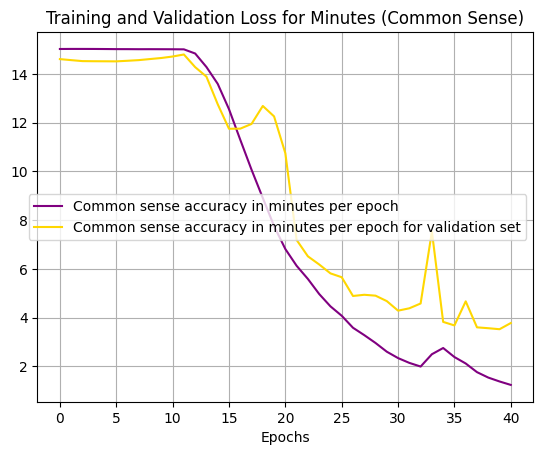

In [ ]:
# Plot common sense MAE per epoch (only for minutes)
plot_loss_accuracy("minute_prediction_circular_mae_minutes", "val_minute_prediction_circular_mae_minutes", history_two_head_model_11, "Minutes (Common Sense)")


In [ ]:
input_ = keras.layers.Input(shape = x_75_train.shape[1:])

# COMMON FEATURE EXTRACTION LAYERS

## Hidden layers uses Conv2D so it can learn spatial patterns from the images, code found on pg. 455 of the book

# Start with convolutional layer with kernel of size 5 x 5 as recommended on page 461 of the book
hidden1 = keras.layers.Conv2D(filters = 30, kernel_size = 5, strides = 2, padding = "same", activation="relu")(input_)
hidden1_norm = keras.layers.BatchNormalization()(hidden1)
max_pooling_deep_1 = keras.layers.MaxPooling2D(2)(hidden1_norm)
hidden2 = keras.layers.Conv2D(filters = 75, kernel_size = 3, strides = 1, padding = "same", activation="relu")(max_pooling_deep_1)
hidden2_norm = keras.layers.BatchNormalization()(hidden2)
hidden3 = keras.layers.Conv2D(filters = 150, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden2_norm)
hidden3_norm = keras.layers.BatchNormalization()(hidden3)

# Add one more layer for better learning
hidden4= keras.layers.Conv2D(filters = 300, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden2_norm)
hidden4_norm = keras.layers.BatchNormalization()(hidden4)



# We add a skip layer here in order to feed the outputs through this layer during backpropagation as well

# In order for that to work first the dimensions of hidden2_norm and hidden3_norm need to be the same so we apply the transformation:
hidden2_resized = keras.layers.Conv2D(150, kernel_size=1, strides=1, padding="same")(hidden2_norm)
skip = keras.layers.Add()([hidden2_resized, hidden3_norm])
skip_norm = keras.layers.BatchNormalization()(skip)
skip_act = keras.layers.Activation("relu")(skip_norm) # Add activation also after the skip layer
max_pooling_deep_2 = keras.layers.MaxPooling2D(2)(skip_act)

# Add another skip layer along with the new convolutional layer
hidden3_resized = keras.layers.Conv2D(300, kernel_size=1, strides=1, padding="same")(hidden3_norm)
skip_2 = keras.layers.Add()([hidden3_resized, hidden4_norm])
skip_norm_2 = keras.layers.BatchNormalization()(skip_2)
skip_act_2 = keras.layers.Activation("relu")(skip_norm_2) # Add activation also after the skip layer
max_pooling_deep_3 = keras.layers.MaxPooling2D(2)(skip_act_2)


# Flatten output before passing to the dense layers
flattened = keras.layers.Flatten()(max_pooling_deep_3)

# HOUR RECOGNITION LAYERS
hidden_hours = keras.layers.Dense(60, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(flattened)
hidden_hours = keras.layers.Dropout(0.1)(hidden_hours)
hidden_hours = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_hours)
output_hours = keras.layers.Dense(12, name = "hour_prediction", activation="softmax", kernel_regularizer = keras.regularizers.l2(0.001)) (hidden_hours)

# MINUTE RECOGNITION LAYERS
hidden_minutes = keras.layers.Dense(30, activation= "relu", kernel_regularizer = keras.regularizers.l2(0.001))(flattened)
hidden_minutes_norm = keras.layers.LayerNormalization()(hidden_minutes)
hidden_minutes_2 = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_norm)
hidden_minutes_2_norm = keras.layers.LayerNormalization()(hidden_minutes_2)
output_minutes = keras.layers.Dense(1, name = "minute_prediction", activation="linear", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_2_norm)

two_head_model_12 = keras.Model(inputs=input_, outputs=[output_hours, output_minutes])

two_head_model_12.compile(loss = {"hour_prediction": "categorical_crossentropy", "minute_prediction": "mse"},
                    optimizer=keras.optimizers.Adam(learning_rate = 0.0001),
                    metrics={"minute_prediction":circular_mae_minutes},
                    loss_weights = {"hour_prediction": 0.7, "minute_prediction": 0.3})

history_two_head_model_12 = two_head_model_12.fit(x_75_train,
                                            {"hour_prediction": y_75_train_hour,
                                            "minute_prediction":y_75_train_minutes},
                                            epochs=50,
                                            validation_data=(x_75_validation,
                                                            {"hour_prediction": y_75_validation_hour,
                                                            "minute_prediction": y_75_validation_minutes}),
                                            callbacks = [keras.callbacks.EarlyStopping(monitor = "val_loss", patience = 10, restore_best_weights = True)]
                                                )

# Save the model so we can use it even if runtime ends
two_head_model_12.save("two_head_model_12.keras")

Epoch 1/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - hour_prediction_loss: 2.5342 - loss: 289.4039 - minute_prediction_circular_mae_minutes: 15.0714 - minute_prediction_loss: 958.0220 - val_hour_prediction_loss: 2.4852 - val_loss: 263.7276 - val_minute_prediction_circular_mae_minutes: 14.6516 - val_minute_prediction_loss: 871.4637
Epoch 2/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - hour_prediction_loss: 2.4938 - loss: 270.8954 - minute_prediction_circular_mae_minutes: 15.0795 - minute_prediction_loss: 896.5452 - val_hour_prediction_loss: 2.4869 - val_loss: 245.9471 - val_minute_prediction_circular_mae_minutes: 14.5984 - val_minute_prediction_loss: 812.3597
Epoch 3/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - hour_prediction_loss: 2.4847 - loss: 252.3549 - minute_prediction_circular_mae_minutes: 15.0906 - minute_prediction_loss: 834.8541 - val_hour_prediction_loss: 2.4864 - val_loss: 227.6510 - val_minute_prediction_circular_mae_minutes: 14.5578 - val_minute_prediction_loss: 751

In [ ]:
# Compute the common sense MAE for the hours
common_sense_mae_hours_mod_12 = circular_mae_two_head(two_head_model_12, x_75_test, y_75_test)

# Print the output on the minutes scale
error_in_minutes_model_12 = common_sense_mae_hours_mod_12 * 720
print("Common sense error in minutes for model 12: ", error_in_minutes_model_12)

57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step
Common sense error in minutes for model 11:  38.833888888888886


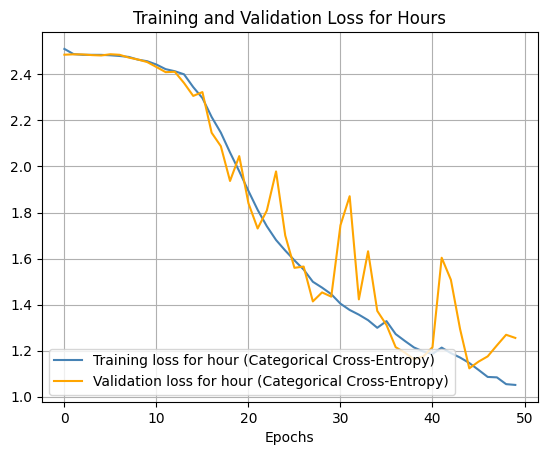

In [ ]:
# Plot hour loss per epoch
plot_loss_accuracy("hour_prediction_loss", "val_hour_prediction_loss", history_two_head_model_12, "Hours")

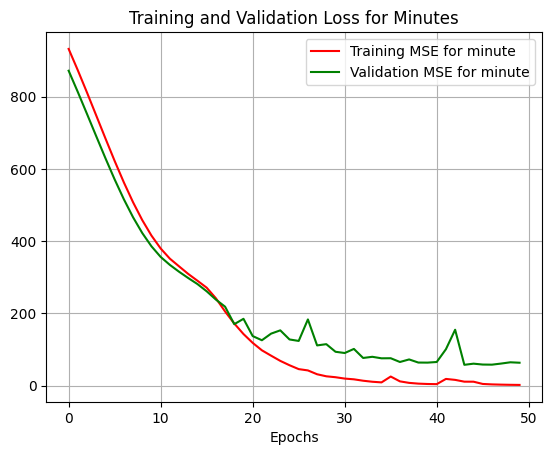

In [ ]:
# Plot hour loss per epoch
plot_loss_accuracy("minute_prediction_loss", "val_minute_prediction_loss", history_two_head_model_12, "Minutes")

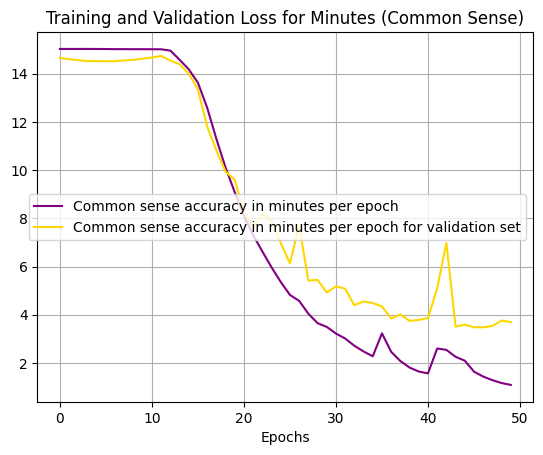

In [ ]:
# Plot common sense MAE per epoch (only for minutes)
plot_loss_accuracy("minute_prediction_circular_mae_minutes", "val_minute_prediction_circular_mae_minutes", history_two_head_model_12, "Minutes (Common Sense)")


Thirteenth trial: Above, the minutes still overfit after some epochs and the hours could still improve more. We re-weigh again.

In [ ]:
input_ = keras.layers.Input(shape = x_75_train.shape[1:])

# COMMON FEATURE EXTRACTION LAYERS

## Hidden layers uses Conv2D so it can learn spatial patterns from the images, code found on pg. 455 of the book

# Start with convolutional layer with kernel of size 5 x 5 as recommended on page 461 of the book
hidden1 = keras.layers.Conv2D(filters = 30, kernel_size = 5, strides = 2, padding = "same", activation="relu")(input_)
hidden1_norm = keras.layers.BatchNormalization()(hidden1)
max_pooling_deep_1 = keras.layers.MaxPooling2D(2)(hidden1_norm)
hidden2 = keras.layers.Conv2D(filters = 75, kernel_size = 3, strides = 1, padding = "same", activation="relu")(max_pooling_deep_1)
hidden2_norm = keras.layers.BatchNormalization()(hidden2)
hidden3 = keras.layers.Conv2D(filters = 150, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden2_norm)
hidden3_norm = keras.layers.BatchNormalization()(hidden3)

# Add one more layer for better learning
hidden4= keras.layers.Conv2D(filters = 300, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden2_norm)
hidden4_norm = keras.layers.BatchNormalization()(hidden4)



# We add a skip layer here in order to feed the outputs through this layer during backpropagation as well

# In order for that to work first the dimensions of hidden2_norm and hidden3_norm need to be the same so we apply the transformation:
hidden2_resized = keras.layers.Conv2D(150, kernel_size=1, strides=1, padding="same")(hidden2_norm)
skip = keras.layers.Add()([hidden2_resized, hidden3_norm])
skip_norm = keras.layers.BatchNormalization()(skip)
skip_act = keras.layers.Activation("relu")(skip_norm) # Add activation also after the skip layer
max_pooling_deep_2 = keras.layers.MaxPooling2D(2)(skip_act)

# Add another skip layer along with the new convolutional layer
hidden3_resized = keras.layers.Conv2D(300, kernel_size=1, strides=1, padding="same")(hidden3_norm)
skip_2 = keras.layers.Add()([hidden3_resized, hidden4_norm])
skip_norm_2 = keras.layers.BatchNormalization()(skip_2)
skip_act_2 = keras.layers.Activation("relu")(skip_norm_2) # Add activation also after the skip layer
max_pooling_deep_3 = keras.layers.MaxPooling2D(2)(skip_act_2)


# Flatten output before passing to the dense layers
flattened = keras.layers.Flatten()(max_pooling_deep_3)

# HOUR RECOGNITION LAYERS
hidden_hours = keras.layers.Dense(60, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(flattened)
hidden_hours = keras.layers.Dropout(0.1)(hidden_hours)
hidden_hours = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_hours)
output_hours = keras.layers.Dense(12, name = "hour_prediction", activation="softmax", kernel_regularizer = keras.regularizers.l2(0.001)) (hidden_hours)

# MINUTE RECOGNITION LAYERS
hidden_minutes = keras.layers.Dense(30, activation= "relu", kernel_regularizer = keras.regularizers.l2(0.001))(flattened)
hidden_minutes_norm = keras.layers.LayerNormalization()(hidden_minutes)
hidden_minutes_2 = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_norm)
hidden_minutes_2_norm = keras.layers.LayerNormalization()(hidden_minutes_2)
output_minutes = keras.layers.Dense(1, name = "minute_prediction", activation="linear", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_2_norm)

two_head_model_13 = keras.Model(inputs=input_, outputs=[output_hours, output_minutes])

two_head_model_13.compile(loss = {"hour_prediction": "categorical_crossentropy", "minute_prediction": "mse"},
                    optimizer=keras.optimizers.Adam(learning_rate = 0.0001),
                    metrics={"minute_prediction":circular_mae_minutes},
                    loss_weights = {"hour_prediction": 0.9, "minute_prediction": 0.1})

history_two_head_model_13 = two_head_model_13.fit(x_75_train,
                                            {"hour_prediction": y_75_train_hour,
                                            "minute_prediction":y_75_train_minutes},
                                            epochs=50,
                                            validation_data=(x_75_validation,
                                                            {"hour_prediction": y_75_validation_hour,
                                                            "minute_prediction": y_75_validation_minutes}),
                                            callbacks = [keras.callbacks.EarlyStopping(monitor = "val_loss", patience = 10, restore_best_weights = True)]
                                                )

# Save the model so we can use it even if runtime ends
two_head_model_13.save("two_head_model_13.keras")

Epoch 1/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - hour_prediction_loss: 2.5759 - loss: 97.5967 - minute_prediction_circular_mae_minutes: 15.0721 - minute_prediction_loss: 950.5396 - val_hour_prediction_loss: 2.4850 - val_loss: 88.8991 - val_minute_prediction_circular_mae_minutes: 14.6442 - val_minute_prediction_loss: 863.4727
Epoch 2/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - hour_prediction_loss: 2.4850 - loss: 91.1764 - minute_prediction_circular_mae_minutes: 15.0812 - minute_prediction_loss: 887.4852 - val_hour_prediction_loss: 2.4851 - val_loss: 82.7836 - val_minute_prediction_circular_mae_minutes: 14.5910 - val_minute_prediction_loss: 802.6346
Epoch 3/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - hour_prediction_loss: 2.4850 - loss: 84.8295 - minute_prediction_circular_mae_minutes: 15.0922 - minute_prediction_loss: 824.2437 - val_hour_prediction_loss: 2.4845 - val_loss: 76.4818 - val_minute_prediction_circular_mae_minutes: 14.5512 - val_minute_prediction_loss: 739.9036

In [ ]:
# Compute the common sense MAE for the hours
common_sense_mae_hours_mod_13 = circular_mae_two_head(two_head_model_13, x_75_test, y_75_test)

# Print the output on the minutes scale
error_in_minutes_model_13 = common_sense_mae_hours_mod_13 * 720
print("Common sense error in minutes for model 13: ", error_in_minutes_model_13)

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step
Common sense error in minutes for model 11:  79.825


In [ ]:
input_ = keras.layers.Input(shape = x_75_train.shape[1:])

# COMMON FEATURE EXTRACTION LAYERS

## Hidden layers uses Conv2D so it can learn spatial patterns from the images, code found on pg. 455 of the book

# Start with convolutional layer with kernel of size 5 x 5 as recommended on page 461 of the book
hidden1 = keras.layers.Conv2D(filters = 30, kernel_size = 5, strides = 2, padding = "same", activation="relu")(input_)
hidden1_norm = keras.layers.BatchNormalization()(hidden1)
max_pooling_deep_1 = keras.layers.MaxPooling2D(2)(hidden1_norm)
hidden2 = keras.layers.Conv2D(filters = 75, kernel_size = 3, strides = 1, padding = "same", activation="relu")(max_pooling_deep_1)
hidden2_norm = keras.layers.BatchNormalization()(hidden2)
hidden3 = keras.layers.Conv2D(filters = 150, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden2_norm)
hidden3_norm = keras.layers.BatchNormalization()(hidden3)

# Add one more layer for better learning
hidden4= keras.layers.Conv2D(filters = 300, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden3_norm)
hidden4_norm = keras.layers.BatchNormalization()(hidden4)

# Add another more layer for better learning
hidden5= keras.layers.Conv2D(filters = 360, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden4_norm)
hidden5_norm = keras.layers.BatchNormalization()(hidden5)



# We add a skip layer here in order to feed the outputs through this layer during backpropagation as well

# In order for that to work first the dimensions of hidden2_norm and hidden3_norm need to be the same so we apply the transformation:
hidden2_resized = keras.layers.Conv2D(150, kernel_size=1, strides=1, padding="same")(hidden2_norm)
skip = keras.layers.Add()([hidden2_resized, hidden3_norm])
skip_norm = keras.layers.BatchNormalization()(skip)
skip_act = keras.layers.Activation("relu")(skip_norm) # Add activation also after the skip layer
max_pooling_deep_2 = keras.layers.MaxPooling2D(2)(skip_act)

# Add another skip layer along with the new convolutional layer
hidden3_resized = keras.layers.Conv2D(300, kernel_size=1, strides=1, padding="same")(hidden3_norm)
skip_2 = keras.layers.Add()([hidden3_resized, hidden4_norm])
skip_norm_2 = keras.layers.BatchNormalization()(skip_2)
skip_act_2 = keras.layers.Activation("relu")(skip_norm_2) # Add activation also after the skip layer
max_pooling_deep_3 = keras.layers.MaxPooling2D(2)(skip_act_2)

# Yet another skip layer for the new convolutional layer
hidden4_resized = keras.layers.Conv2D(360, kernel_size=1, strides=1, padding="same")(hidden4_norm)
skip_3 = keras.layers.Add()([hidden4_resized, hidden5_norm])
skip_norm_3 = keras.layers.BatchNormalization()(skip_3)
skip_act_3 = keras.layers.Activation("relu")(skip_norm_3) # Add activation also after the skip layer
max_pooling_deep_4 = keras.layers.MaxPooling2D(2)(skip_act_3)


# Flatten output before passing to the dense layers
flattened = keras.layers.Flatten()(max_pooling_deep_4)

# HOUR RECOGNITION LAYERS
hidden_hours = keras.layers.Dense(60, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(flattened)
hidden_hours = keras.layers.Dropout(0.1)(hidden_hours)
hidden_hours = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_hours)
output_hours = keras.layers.Dense(12, name = "hour_prediction", activation="softmax", kernel_regularizer = keras.regularizers.l2(0.001)) (hidden_hours)

# MINUTE RECOGNITION LAYERS
hidden_minutes = keras.layers.Dense(30, activation= "relu", kernel_regularizer = keras.regularizers.l2(0.001))(flattened)
hidden_minutes_norm = keras.layers.LayerNormalization()(hidden_minutes)
hidden_minutes_2 = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_norm)
hidden_minutes_2_norm = keras.layers.LayerNormalization()(hidden_minutes_2)
output_minutes = keras.layers.Dense(1, name = "minute_prediction", activation="linear", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_2_norm)

two_head_model_14 = keras.Model(inputs=input_, outputs=[output_hours, output_minutes])

two_head_model_14.compile(loss = {"hour_prediction": "categorical_crossentropy", "minute_prediction": "mse"},
                    optimizer=keras.optimizers.Adam(learning_rate = 0.0001),
                    metrics={"minute_prediction":circular_mae_minutes},
                    loss_weights = {"hour_prediction": 0.9, "minute_prediction": 0.1})

history_two_head_model_14 = two_head_model_14.fit(x_75_train,
                                            {"hour_prediction": y_75_train_hour,
                                            "minute_prediction":y_75_train_minutes},
                                            epochs=50,
                                            validation_data=(x_75_validation,
                                                            {"hour_prediction": y_75_validation_hour,
                                                            "minute_prediction": y_75_validation_minutes}),
                                            callbacks = [keras.callbacks.EarlyStopping(monitor = "val_loss", patience = 10, restore_best_weights = True)]
                                                )

# Save the model so we can use it even if runtime ends
two_head_model_14.save("two_head_model_14.keras")

Epoch 1/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 94s 52ms/step - hour_prediction_loss: 2.5523 - loss: 93.8118 - minute_prediction_circular_mae_minutes: 15.0754 - minute_prediction_loss: 912.9334 - val_hour_prediction_loss: 2.4850 - val_loss: 84.6202 - val_minute_prediction_circular_mae_minutes: 14.6041 - val_minute_prediction_loss: 820.7283
Epoch 2/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - hour_prediction_loss: 2.5080 - loss: 86.7153 - minute_prediction_circular_mae_minutes: 15.0894 - minute_prediction_loss: 842.6536 - val_hour_prediction_loss: 2.4858 - val_loss: 78.4920 - val_minute_prediction_circular_mae_minutes: 14.5622 - val_minute_prediction_loss: 759.7461
Epoch 3/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - hour_prediction_loss: 2.4973 - loss: 80.3832 - minute_prediction_circular_mae_minutes: 15.0994 - minute_prediction_loss: 779.6471 - val_hour_prediction_loss: 2.4845 - val_loss: 72.2482 - val_minute_prediction_circular_mae_minutes: 14.5204 - val_minute_prediction_loss: 697.601

In [ ]:
# Compute the common sense MAE for the hours
common_sense_mae_hours_mod_14 = circular_mae_two_head(two_head_model_14, x_75_test, y_75_test)

# Print the output on the minutes scale
error_in_minutes_model_14 = common_sense_mae_hours_mod_14 * 720
print("Common sense error in minutes for model 14: ", error_in_minutes_model_14)

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step
Common sense error in minutes for model 14:  20.525000000000002


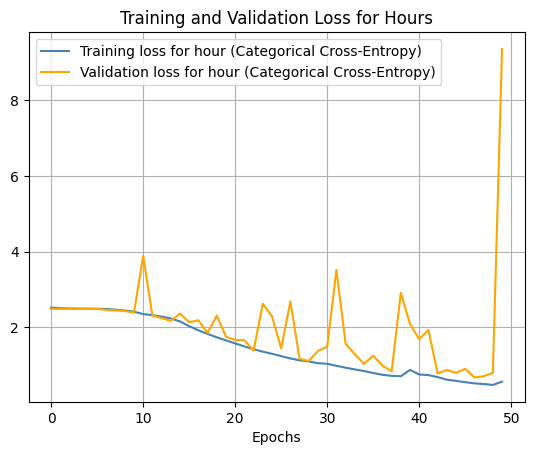

In [ ]:
# Plot hour loss per epoch
plot_loss_accuracy("hour_prediction_loss", "val_hour_prediction_loss", history_two_head_model_14, "Hours")

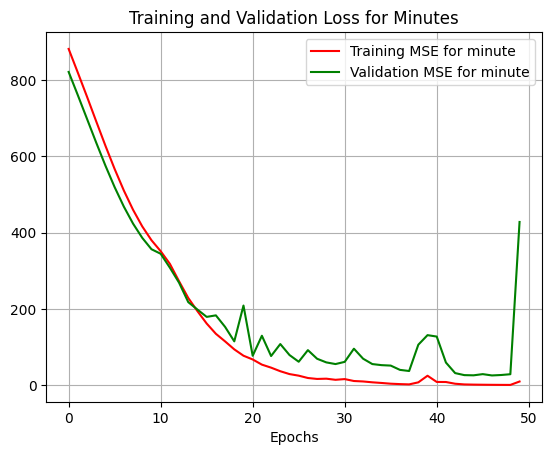

In [ ]:
# Plot hour loss per epoch
plot_loss_accuracy("minute_prediction_loss", "val_minute_prediction_loss", history_two_head_model_14, "Minutes")

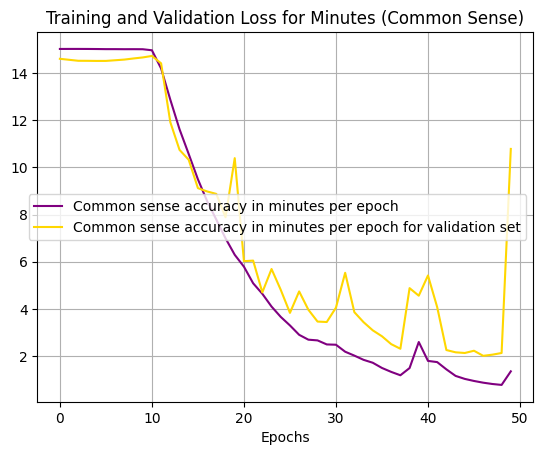

In [ ]:
# Plot common sense MAE per epoch (only for minutes)
plot_loss_accuracy("minute_prediction_circular_mae_minutes", "val_minute_prediction_circular_mae_minutes", history_two_head_model_14, "Minutes (Common Sense)")


In [ ]:
input_ = keras.layers.Input(shape = x_75_train.shape[1:])

# COMMON FEATURE EXTRACTION LAYERS

## Hidden layers uses Conv2D so it can learn spatial patterns from the images, code found on pg. 455 of the book

# Start with convolutional layer with kernel of size 5 x 5 as recommended on page 461 of the book
hidden1 = keras.layers.Conv2D(filters = 30, kernel_size = 5, strides = 2, padding = "same", activation="relu")(input_)
hidden1_norm = keras.layers.BatchNormalization()(hidden1)
max_pooling_deep_1 = keras.layers.MaxPooling2D(2)(hidden1_norm)
hidden2 = keras.layers.Conv2D(filters = 75, kernel_size = 3, strides = 1, padding = "same", activation="relu")(max_pooling_deep_1)
hidden2_norm = keras.layers.BatchNormalization()(hidden2)
hidden3 = keras.layers.Conv2D(filters = 150, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden2_norm)
hidden3_norm = keras.layers.BatchNormalization()(hidden3)

# Add one more layer for better learning
hidden4= keras.layers.Conv2D(filters = 300, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden3_norm)
hidden4_norm = keras.layers.BatchNormalization()(hidden4)

# Add another more layer for better learning
hidden5= keras.layers.Conv2D(filters = 360, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden4_norm)
hidden5_norm = keras.layers.BatchNormalization()(hidden5)



# We add a skip layer here in order to feed the outputs through this layer during backpropagation as well

# In order for that to work first the dimensions of hidden2_norm and hidden3_norm need to be the same so we apply the transformation:
hidden2_resized = keras.layers.Conv2D(150, kernel_size=1, strides=1, padding="same")(hidden2_norm)
skip = keras.layers.Add()([hidden2_resized, hidden3_norm])
skip_norm = keras.layers.BatchNormalization()(skip)
skip_act = keras.layers.Activation("relu")(skip_norm) # Add activation also after the skip layer
max_pooling_deep_2 = keras.layers.MaxPooling2D(2)(skip_act)

# Add another skip layer along with the new convolutional layer
hidden3_resized = keras.layers.Conv2D(300, kernel_size=1, strides=1, padding="same")(hidden3_norm)
skip_2 = keras.layers.Add()([hidden3_resized, hidden4_norm])
skip_norm_2 = keras.layers.BatchNormalization()(skip_2)
skip_act_2 = keras.layers.Activation("relu")(skip_norm_2) # Add activation also after the skip layer
max_pooling_deep_3 = keras.layers.MaxPooling2D(2)(skip_act_2)

# Yet another skip layer for the new convolutional layer
hidden4_resized = keras.layers.Conv2D(360, kernel_size=1, strides=1, padding="same")(hidden4_norm)
skip_3 = keras.layers.Add()([hidden4_resized, hidden5_norm])
skip_norm_3 = keras.layers.BatchNormalization()(skip_3)
skip_act_3 = keras.layers.Activation("relu")(skip_norm_3) # Add activation also after the skip layer
max_pooling_deep_4 = keras.layers.MaxPooling2D(2)(skip_act_3)


# Flatten output before passing to the dense layers
flattened = keras.layers.Flatten()(max_pooling_deep_4)

# HOUR RECOGNITION LAYERS
hidden_hours = keras.layers.Dense(60, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.005))(flattened)
hidden_hours = keras.layers.Dropout(0.1)(hidden_hours)
hidden_hours = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.005))(hidden_hours)
output_hours = keras.layers.Dense(12, name = "hour_prediction", activation="softmax", kernel_regularizer = keras.regularizers.l2(0.001)) (hidden_hours)

# MINUTE RECOGNITION LAYERS
hidden_minutes = keras.layers.Dense(30, activation= "relu", kernel_regularizer = keras.regularizers.l2(0.005))(flattened)
hidden_minutes_norm = keras.layers.LayerNormalization()(hidden_minutes)
hidden_minutes_2 = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.005))(hidden_minutes_norm)
hidden_minutes_2_norm = keras.layers.LayerNormalization()(hidden_minutes_2)
output_minutes = keras.layers.Dense(1, name = "minute_prediction", activation="linear", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_2_norm)

two_head_model_15 = keras.Model(inputs=input_, outputs=[output_hours, output_minutes])

two_head_model_15.compile(loss = {"hour_prediction": "categorical_crossentropy", "minute_prediction": "mse"},
                    optimizer=keras.optimizers.Adam(learning_rate = 0.0001),
                    metrics={"minute_prediction":circular_mae_minutes},
                    loss_weights = {"hour_prediction": 0.9, "minute_prediction": 0.1})

history_two_head_model_15 = two_head_model_15.fit(x_75_train,
                                            {"hour_prediction": y_75_train_hour,
                                            "minute_prediction":y_75_train_minutes},
                                            epochs=50,
                                            validation_data=(x_75_validation,
                                                            {"hour_prediction": y_75_validation_hour,
                                                            "minute_prediction": y_75_validation_minutes}),
                                            callbacks = [keras.callbacks.EarlyStopping(monitor = "val_loss", patience = 10, restore_best_weights = True)]
                                                )

# Save the model so we can use it even if runtime ends
two_head_model_15.save("two_head_model_15.keras")

Epoch 1/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 47s 73ms/step - hour_prediction_loss: 2.5464 - loss: 100.6813 - minute_prediction_circular_mae_minutes: 15.0641 - minute_prediction_loss: 973.7252 - val_hour_prediction_loss: 2.4849 - val_loss: 91.7655 - val_minute_prediction_circular_mae_minutes: 14.6669 - val_minute_prediction_loss: 886.3871
Epoch 2/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - hour_prediction_loss: 2.5008 - loss: 94.2699 - minute_prediction_circular_mae_minutes: 15.0759 - minute_prediction_loss: 913.0129 - val_hour_prediction_loss: 2.4849 - val_loss: 85.9166 - val_minute_prediction_circular_mae_minutes: 14.6128 - val_minute_prediction_loss: 829.7983
Epoch 3/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - hour_prediction_loss: 2.4935 - loss: 88.1359 - minute_prediction_circular_mae_minutes: 15.0875 - minute_prediction_loss: 853.3781 - val_hour_prediction_loss: 2.4850 - val_loss: 78.2542 - val_minute_prediction_circular_mae_minutes: 14.5593 - val_minute_prediction_loss: 754.46

In [ ]:
# Compute the common sense MAE for the hours
common_sense_mae_hours_mod_15 = circular_mae_two_head(two_head_model_15, x_75_test, y_75_test)

# Print the output on the minutes scale
error_in_minutes_model_15 = common_sense_mae_hours_mod_15 * 720
print("Common sense error in minutes for model 15: ", error_in_minutes_model_15)

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step
Common sense error in minutes for model 15:  25.18722222222222


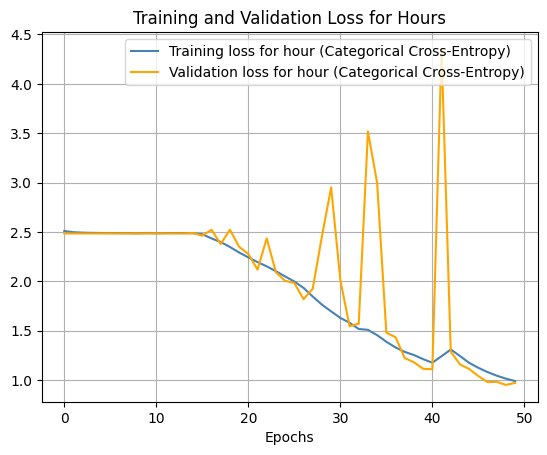

In [ ]:
# Plot hour loss per epoch
plot_loss_accuracy("hour_prediction_loss", "val_hour_prediction_loss", history_two_head_model_15, "Hours")

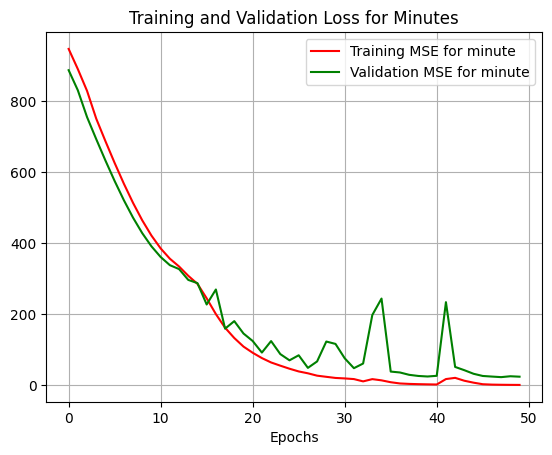

In [ ]:
# Plot hour loss per epoch
plot_loss_accuracy("minute_prediction_loss", "val_minute_prediction_loss", history_two_head_model_15, "Minutes")

Sixteenth trial: We finally reach a decently low common sense error but the jumps in the validation losses point to some instability especially after epoch 10. So we need to decrease the learning rate with a scheduler, after epoch 15 perhaps.

In [ ]:
input_ = keras.layers.Input(shape = x_75_train.shape[1:])

# From keras documentation: https://keras.io/api/callbacks/learning_rate_scheduler/
def learn_schedule(epoch, rate):
  if epoch < 20:
    return rate
  else:
    return rate * 0.9


# COMMON FEATURE EXTRACTION LAYERS

## Hidden layers uses Conv2D so it can learn spatial patterns from the images, code found on pg. 455 of the book

# Start with convolutional layer with kernel of size 5 x 5 as recommended on page 461 of the book
hidden1 = keras.layers.Conv2D(filters = 30, kernel_size = 5, strides = 2, padding = "same", activation="relu")(input_)
hidden1_norm = keras.layers.BatchNormalization()(hidden1)
max_pooling_deep_1 = keras.layers.MaxPooling2D(2)(hidden1_norm)
hidden2 = keras.layers.Conv2D(filters = 75, kernel_size = 3, strides = 1, padding = "same", activation="relu")(max_pooling_deep_1)
hidden2_norm = keras.layers.BatchNormalization()(hidden2)
hidden3 = keras.layers.Conv2D(filters = 150, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden2_norm)
hidden3_norm = keras.layers.BatchNormalization()(hidden3)

# Add one more layer for better learning
hidden4= keras.layers.Conv2D(filters = 300, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden3_norm)
hidden4_norm = keras.layers.BatchNormalization()(hidden4)

# Add another more layer for better learning
hidden5= keras.layers.Conv2D(filters = 360, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden4_norm)
hidden5_norm = keras.layers.BatchNormalization()(hidden5)



# We add a skip layer here in order to feed the outputs through this layer during backpropagation as well

# In order for that to work first the dimensions of hidden2_norm and hidden3_norm need to be the same so we apply the transformation:
hidden2_resized = keras.layers.Conv2D(150, kernel_size=1, strides=1, padding="same")(hidden2_norm)
skip = keras.layers.Add()([hidden2_resized, hidden3_norm])
skip_norm = keras.layers.BatchNormalization()(skip)
skip_act = keras.layers.Activation("relu")(skip_norm) # Add activation also after the skip layer
max_pooling_deep_2 = keras.layers.MaxPooling2D(2)(skip_act)

# Add another skip layer along with the new convolutional layer
hidden3_resized = keras.layers.Conv2D(300, kernel_size=1, strides=1, padding="same")(hidden3_norm)
skip_2 = keras.layers.Add()([hidden3_resized, hidden4_norm])
skip_norm_2 = keras.layers.BatchNormalization()(skip_2)
skip_act_2 = keras.layers.Activation("relu")(skip_norm_2) # Add activation also after the skip layer
max_pooling_deep_3 = keras.layers.MaxPooling2D(2)(skip_act_2)

# Yet another skip layer for the new convolutional layer
hidden4_resized = keras.layers.Conv2D(360, kernel_size=1, strides=1, padding="same")(hidden4_norm)
skip_3 = keras.layers.Add()([hidden4_resized, hidden5_norm])
skip_norm_3 = keras.layers.BatchNormalization()(skip_3)
skip_act_3 = keras.layers.Activation("relu")(skip_norm_3) # Add activation also after the skip layer
max_pooling_deep_4 = keras.layers.MaxPooling2D(2)(skip_act_3)


# Flatten output before passing to the dense layers
flattened = keras.layers.Flatten()(max_pooling_deep_4)

# HOUR RECOGNITION LAYERS
hidden_hours = keras.layers.Dense(60, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.005))(flattened)
hidden_hours = keras.layers.Dropout(0.1)(hidden_hours)
hidden_hours = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.005))(hidden_hours)
output_hours = keras.layers.Dense(12, name = "hour_prediction", activation="softmax", kernel_regularizer = keras.regularizers.l2(0.001)) (hidden_hours)

# MINUTE RECOGNITION LAYERS
hidden_minutes = keras.layers.Dense(30, activation= "relu", kernel_regularizer = keras.regularizers.l2(0.005))(flattened)
hidden_minutes_norm = keras.layers.LayerNormalization()(hidden_minutes)
hidden_minutes_2 = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.005))(hidden_minutes_norm)
hidden_minutes_2_norm = keras.layers.LayerNormalization()(hidden_minutes_2)
output_minutes = keras.layers.Dense(1, name = "minute_prediction", activation="linear", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_2_norm)

two_head_model_16 = keras.Model(inputs=input_, outputs=[output_hours, output_minutes])

two_head_model_16.compile(loss = {"hour_prediction": "categorical_crossentropy", "minute_prediction": "mse"},
                    optimizer=keras.optimizers.Adam(learning_rate = 0.0009),
                    metrics={"minute_prediction":circular_mae_minutes},
                    loss_weights = {"hour_prediction": 0.9, "minute_prediction": 0.1})

history_two_head_model_16 = two_head_model_16.fit(x_75_train,
                                            {"hour_prediction": y_75_train_hour,
                                            "minute_prediction":y_75_train_minutes},
                                            epochs=50,
                                            validation_data=(x_75_validation,
                                                            {"hour_prediction": y_75_validation_hour,
                                                            "minute_prediction": y_75_validation_minutes}),
                                            callbacks = [keras.callbacks.EarlyStopping(monitor = "val_loss", patience = 10, restore_best_weights = True), keras.callbacks.LearningRateScheduler(learn_schedule)]
                                                )

# Save the model so we can use it even if runtime ends
two_head_model_16.save("two_head_model_16.keras")

Epoch 1/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - hour_prediction_loss: 2.5448 - loss: 99.1024 - minute_prediction_circular_mae_minutes: 15.0685 - minute_prediction_loss: 957.7570 - val_hour_prediction_loss: 2.4859 - val_loss: 90.1788 - val_minute_prediction_circular_mae_minutes: 14.6508 - val_minute_prediction_loss: 870.2914 - learning_rate: 1.0000e-04
Epoch 2/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - hour_prediction_loss: 2.4985 - loss: 92.5817 - minute_prediction_circular_mae_minutes: 15.0798 - minute_prediction_loss: 895.9393 - val_hour_prediction_loss: 2.4849 - val_loss: 84.2723 - val_minute_prediction_circular_mae_minutes: 14.5990 - val_minute_prediction_loss: 813.2408 - learning_rate: 1.0000e-04
Epoch 3/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - hour_prediction_loss: 2.4846 - loss: 86.4432 - minute_prediction_circular_mae_minutes: 15.0904 - minute_prediction_loss: 836.4124 - val_hour_prediction_loss: 2.4845 - val_loss: 78.3182 - val_minute_prediction_circular_ma

In [ ]:
# Compute the common sense MAE for the hours
common_sense_mae_hours_mod_16 = circular_mae_two_head(two_head_model_16, x_75_test, y_75_test)

# Print the output on the minutes scale
error_in_minutes_model_16 = common_sense_mae_hours_mod_16 * 720
print("Common sense error in minutes for model 16: ", error_in_minutes_model_16)

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Common sense error in minutes for model 16:  40.91722222222222


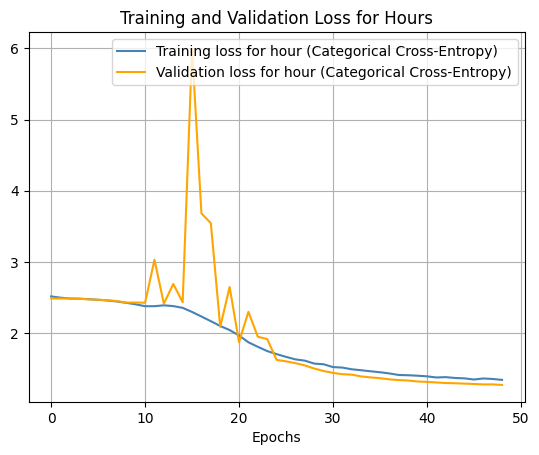

In [ ]:
# Plot hour loss per epoch
plot_loss_accuracy("hour_prediction_loss", "val_hour_prediction_loss", history_two_head_model_16, "Hours")

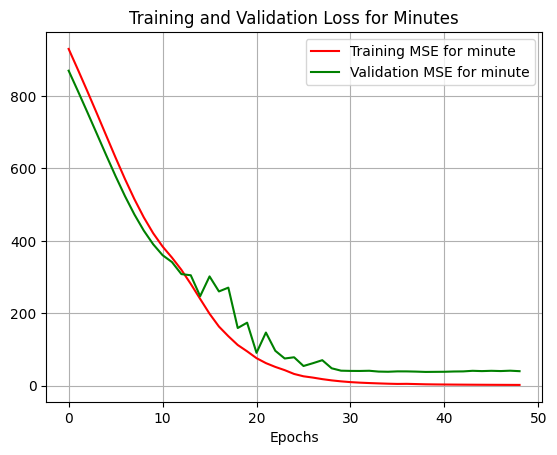

In [ ]:
# Plot hour loss per epoch
plot_loss_accuracy("minute_prediction_loss", "val_minute_prediction_loss", history_two_head_model_16, "Minutes")

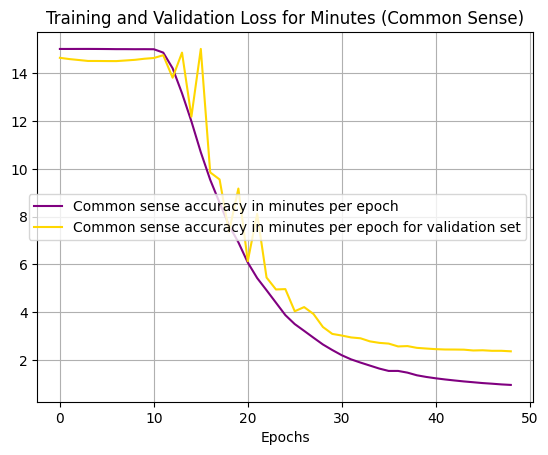

In [ ]:
# Plot common sense MAE per epoch (only for minutes)
plot_loss_accuracy("minute_prediction_circular_mae_minutes", "val_minute_prediction_circular_mae_minutes", history_two_head_model_16, "Minutes (Common Sense)")


In [ ]:
input_ = keras.layers.Input(shape = x_75_train.shape[1:])

# From keras documentation: https://keras.io/api/callbacks/learning_rate_scheduler/
def learn_schedule(epoch, rate):
  if epoch < 35:
    return rate
  else:
    return rate * 0.9


# COMMON FEATURE EXTRACTION LAYERS

## Hidden layers uses Conv2D so it can learn spatial patterns from the images, code found on pg. 455 of the book

# Start with convolutional layer with kernel of size 5 x 5 as recommended on page 461 of the book
hidden1 = keras.layers.Conv2D(filters = 30, kernel_size = 5, strides = 2, padding = "same", activation="relu")(input_)
hidden1_norm = keras.layers.BatchNormalization()(hidden1)
max_pooling_deep_1 = keras.layers.MaxPooling2D(2)(hidden1_norm)
hidden2 = keras.layers.Conv2D(filters = 75, kernel_size = 3, strides = 1, padding = "same", activation="relu")(max_pooling_deep_1)
hidden2_norm = keras.layers.BatchNormalization()(hidden2)
hidden3 = keras.layers.Conv2D(filters = 150, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden2_norm)
hidden3_norm = keras.layers.BatchNormalization()(hidden3)

# Add one more layer for better learning
hidden4= keras.layers.Conv2D(filters = 300, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden3_norm)
hidden4_norm = keras.layers.BatchNormalization()(hidden4)

# Add another more layer for better learning
hidden5= keras.layers.Conv2D(filters = 360, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden4_norm)
hidden5_norm = keras.layers.BatchNormalization()(hidden5)

# Add ANOTHER more layer for better learning
hidden6= keras.layers.Conv2D(filters = 360, kernel_size = 1, strides = 1, padding = "same", activation = "relu")(hidden4_norm)
hidden6_norm = keras.layers.BatchNormalization()(hidden6)


# We add a skip layer here in order to feed the outputs through this layer during backpropagation as well

# In order for that to work first the dimensions of hidden2_norm and hidden3_norm need to be the same so we apply the transformation:
hidden2_resized = keras.layers.Conv2D(150, kernel_size=1, strides=1, padding="same")(hidden2_norm)
skip = keras.layers.Add()([hidden2_resized, hidden3_norm])
skip_norm = keras.layers.BatchNormalization()(skip)
skip_act = keras.layers.Activation("relu")(skip_norm) # Add activation also after the skip layer
max_pooling_deep_2 = keras.layers.MaxPooling2D(2)(skip_act)

# Add another skip layer along with the new convolutional layer
hidden3_resized = keras.layers.Conv2D(300, kernel_size=1, strides=1, padding="same")(hidden3_norm)
skip_2 = keras.layers.Add()([hidden3_resized, hidden4_norm])
skip_norm_2 = keras.layers.BatchNormalization()(skip_2)
skip_act_2 = keras.layers.Activation("relu")(skip_norm_2) # Add activation also after the skip layer
max_pooling_deep_3 = keras.layers.MaxPooling2D(2)(skip_act_2)

# Yet another skip layer for the new convolutional layer
hidden4_resized = keras.layers.Conv2D(360, kernel_size=1, strides=1, padding="same")(hidden4_norm)
skip_3 = keras.layers.Add()([hidden4_resized, hidden5_norm])
skip_norm_3 = keras.layers.BatchNormalization()(skip_3)
skip_act_3 = keras.layers.Activation("relu")(skip_norm_3) # Add activation also after the skip layer
max_pooling_deep_4 = keras.layers.MaxPooling2D(2)(skip_act_3)

# Yet ANOTHER skip layer for the new convolutional layer
hidden5_resized = keras.layers.Conv2D(360, kernel_size=1, strides=1, padding="same")(hidden4_norm)
skip_4 = keras.layers.Add()([hidden5_resized, hidden6_norm])
skip_norm_4 = keras.layers.BatchNormalization()(skip_4)
skip_act_4 = keras.layers.Activation("relu")(skip_norm_4) # Add activation also after the skip layer
max_pooling_deep_5 = keras.layers.MaxPooling2D(2)(skip_act_4)



# Flatten output before passing to the dense layers
flattened = keras.layers.Flatten()(max_pooling_deep_5)

# HOUR RECOGNITION LAYERS
hidden_hours = keras.layers.Dense(60, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.005))(flattened)
hidden_hours = keras.layers.Dropout(0.1)(hidden_hours)
hidden_hours = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.005))(hidden_hours)
output_hours = keras.layers.Dense(12, name = "hour_prediction", activation="softmax", kernel_regularizer = keras.regularizers.l2(0.001)) (hidden_hours)

# MINUTE RECOGNITION LAYERS
hidden_minutes = keras.layers.Dense(30, activation= "relu", kernel_regularizer = keras.regularizers.l2(0.005))(flattened)
hidden_minutes_norm = keras.layers.LayerNormalization()(hidden_minutes)
hidden_minutes_2 = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.005))(hidden_minutes_norm)
hidden_minutes_2_norm = keras.layers.LayerNormalization()(hidden_minutes_2)
output_minutes = keras.layers.Dense(1, name = "minute_prediction", activation="linear", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_2_norm)

two_head_model_17 = keras.Model(inputs=input_, outputs=[output_hours, output_minutes])

two_head_model_17.compile(loss = {"hour_prediction": "categorical_crossentropy", "minute_prediction": "mse"},
                    optimizer=keras.optimizers.Adam(learning_rate = 0.009),
                    metrics={"minute_prediction":circular_mae_minutes},
                    loss_weights = {"hour_prediction": 0.9, "minute_prediction": 0.1})

history_two_head_model_17 = two_head_model_17.fit(x_75_train,
                                            {"hour_prediction": y_75_train_hour,
                                            "minute_prediction":y_75_train_minutes},
                                            epochs=50,
                                            validation_data=(x_75_validation,
                                                            {"hour_prediction": y_75_validation_hour,
                                                            "minute_prediction": y_75_validation_minutes}),
                                            callbacks = [keras.callbacks.EarlyStopping(monitor = "val_loss", patience = 10, restore_best_weights = True), keras.callbacks.LearningRateScheduler(learn_schedule)]
                                                )

# Save the model so we can use it even if runtime ends
two_head_model_17.save("two_head_model_17.keras")

Epoch 1/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 31s 41ms/step - hour_prediction_loss: 3.9600 - loss: 63.1792 - minute_prediction_circular_mae_minutes: 15.2593 - minute_prediction_loss: 490.8854 - val_hour_prediction_loss: 2.4860 - val_loss: 34.5133 - val_minute_prediction_circular_mae_minutes: 15.1193 - val_minute_prediction_loss: 303.0184 - learning_rate: 0.0090
Epoch 2/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - hour_prediction_loss: 2.4901 - loss: 33.4373 - minute_prediction_circular_mae_minutes: 14.9519 - minute_prediction_loss: 298.4769 - val_hour_prediction_loss: 2.4859 - val_loss: 32.9030 - val_minute_prediction_circular_mae_minutes: 15.1109 - val_minute_prediction_loss: 302.7580 - learning_rate: 0.0090
Epoch 3/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - hour_prediction_loss: 2.4880 - loss: 32.3874 - minute_prediction_circular_mae_minutes: 14.9489 - minute_prediction_loss: 298.5839 - val_hour_prediction_loss: 2.4851 - val_loss: 32.6182 - val_minute_prediction_circular_mae_minute

In [ ]:
# Compute the common sense MAE for the hours
common_sense_mae_hours_mod_17 = circular_mae_two_head(two_head_model_17, x_75_test, y_75_test)

# Print the output on the minutes scale
error_in_minutes_model_17 = common_sense_mae_hours_mod_17 * 720
print("Common sense error in minutes for model 17: ", error_in_minutes_model_17)

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step
Common sense error in minutes for model 17:  182.8338888888889


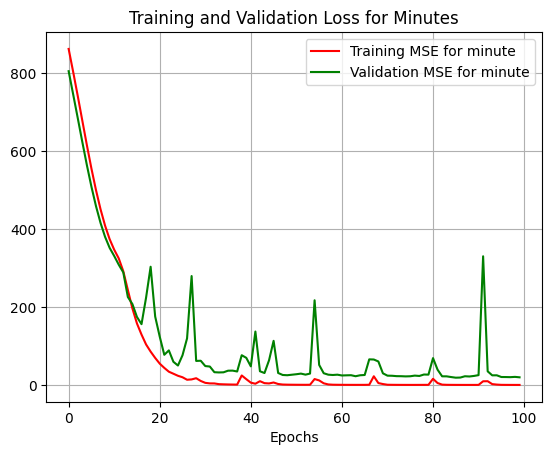

In [ ]:
# Plot minute loss per epoch
plot_loss_accuracy("minute_prediction_loss", "val_minute_prediction_loss", history_two_head_model_14_more_epochs_2, "Minutes")

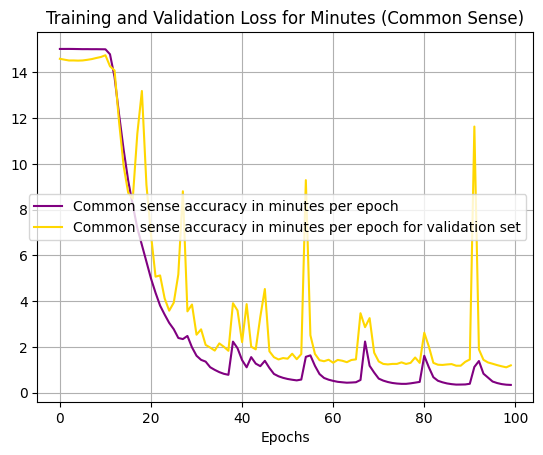

In [ ]:
# Plot common sense MAE per epoch (only for minutes)
plot_loss_accuracy("minute_prediction_circular_mae_minutes", "val_minute_prediction_circular_mae_minutes", history_two_head_model_14_more_epochs_2, "Minutes (Common Sense)")


Try to use sigmoid activation by dividing the minutes by 60 to standardise

In [ ]:
y_75_train_hour = y_75_train[:,0]
y_75_train_minutes_std = y_75_train[:,1]/60

y_75_validation_hour = y_75_validation[:,0]
y_75_validation_minutes_std = y_75_validation[:,1]/60

y_75_test_hour = y_75_test[:,0]
y_75_test_minutes_std = y_75_test[:,1]/60


def circular_mae_minutes_standard(y_true, y_pred):
    """
    Circular MAE for minute values (0-59 scale)
    """
    y_true = tf.cast(tf.squeeze(y_true), tf.float32)
    y_pred = tf.cast(tf.squeeze(y_pred), tf.float32)

    # Calculate circular difference on 0-59 scale
    diff = tf.abs(y_true - y_pred)
    diff_wrapped = tf.minimum(diff, 1 - diff)

    return tf.reduce_mean(diff_wrapped)



In [ ]:
input_ = keras.layers.Input(shape = x_75_train.shape[1:])

# COMMON FEATURE EXTRACTION LAYERS

## Hidden layers uses Conv2D so it can learn spatial patterns from the images, code found on pg. 455 of the book

# Start with convolutional layer with kernel of size 5 x 5 as recommended on page 461 of the book
hidden1 = keras.layers.Conv2D(filters = 30, kernel_size = 5, strides = 2, padding = "same", activation="relu")(input_)
hidden1_norm = keras.layers.BatchNormalization()(hidden1)
max_pooling_deep_1 = keras.layers.MaxPooling2D(2)(hidden1_norm)
hidden2 = keras.layers.Conv2D(filters = 75, kernel_size = 3, strides = 1, padding = "same", activation="relu")(max_pooling_deep_1)
hidden2_norm = keras.layers.BatchNormalization()(hidden2)
hidden3 = keras.layers.Conv2D(filters = 150, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden2_norm)
hidden3_norm = keras.layers.BatchNormalization()(hidden3)

# Add one more layer for better learning
hidden4= keras.layers.Conv2D(filters = 300, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden3_norm)
hidden4_norm = keras.layers.BatchNormalization()(hidden4)

# Add another more layer for better learning
hidden5= keras.layers.Conv2D(filters = 360, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden4_norm)
hidden5_norm = keras.layers.BatchNormalization()(hidden5)



# We add a skip layer here in order to feed the outputs through this layer during backpropagation as well

# In order for that to work first the dimensions of hidden2_norm and hidden3_norm need to be the same so we apply the transformation:
hidden2_resized = keras.layers.Conv2D(150, kernel_size=1, strides=1, padding="same")(hidden2_norm)
skip = keras.layers.Add()([hidden2_resized, hidden3_norm])
skip_norm = keras.layers.BatchNormalization()(skip)
skip_act = keras.layers.Activation("relu")(skip_norm) # Add activation also after the skip layer
max_pooling_deep_2 = keras.layers.MaxPooling2D(2)(skip_act)

# Add another skip layer along with the new convolutional layer
hidden3_resized = keras.layers.Conv2D(300, kernel_size=1, strides=1, padding="same")(hidden3_norm)
skip_2 = keras.layers.Add()([hidden3_resized, hidden4_norm])
skip_norm_2 = keras.layers.BatchNormalization()(skip_2)
skip_act_2 = keras.layers.Activation("relu")(skip_norm_2) # Add activation also after the skip layer
max_pooling_deep_3 = keras.layers.MaxPooling2D(2)(skip_act_2)

# Yet another skip layer for the new convolutional layer
hidden4_resized = keras.layers.Conv2D(360, kernel_size=1, strides=1, padding="same")(hidden4_norm)
skip_3 = keras.layers.Add()([hidden4_resized, hidden5_norm])
skip_norm_3 = keras.layers.BatchNormalization()(skip_3)
skip_act_3 = keras.layers.Activation("relu")(skip_norm_3) # Add activation also after the skip layer
max_pooling_deep_4 = keras.layers.MaxPooling2D(2)(skip_act_3)


# Flatten output before passing to the dense layers
flattened = keras.layers.Flatten()(max_pooling_deep_4)

# HOUR RECOGNITION LAYERS
hidden_hours = keras.layers.Dense(60, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(flattened)
hidden_hours = keras.layers.Dropout(0.1)(hidden_hours)
hidden_hours = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_hours)
output_hours = keras.layers.Dense(12, name = "hour_prediction", activation="softmax", kernel_regularizer = keras.regularizers.l2(0.001)) (hidden_hours)

# MINUTE RECOGNITION LAYERS
hidden_minutes = keras.layers.Dense(30, activation= "relu", kernel_regularizer = keras.regularizers.l2(0.001))(flattened)
hidden_minutes_norm = keras.layers.LayerNormalization()(hidden_minutes)
hidden_minutes_2 = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_norm)
hidden_minutes_2_norm = keras.layers.LayerNormalization()(hidden_minutes_2)
output_minutes = keras.layers.Dense(1, name = "minute_prediction", activation="sigmoid", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_2_norm)

two_head_model_14_more_epochs_sigmoid = keras.Model(inputs=input_, outputs=[output_hours, output_minutes])

two_head_model_14_more_epochs_sigmoid.compile(loss = {"hour_prediction": "sparse_categorical_crossentropy", "minute_prediction": "mse"},
                    optimizer=keras.optimizers.Adam(learning_rate = 0.0001),
                    metrics={"minute_prediction":circular_mae_minutes_standard},
                    loss_weights = {"hour_prediction": 0.9, "minute_prediction": 0.1})

history_two_head_model_14_more_epochs_sigmoid = two_head_model_14_more_epochs_sigmoid.fit(x_75_train,
                                            {"hour_prediction": y_75_train_hour,
                                            "minute_prediction":y_75_train_minutes_std},
                                            epochs=100,
                                            validation_data=(x_75_validation,
                                                            {"hour_prediction": y_75_validation_hour,
                                                            "minute_prediction": y_75_validation_minutes_std}),
                                            callbacks = [keras.callbacks.EarlyStopping(monitor = "val_loss", patience = 10, restore_best_weights = True)]
                                                )

# Save the model so we can use it even if runtime ends
two_head_model_14_more_epochs_sigmoid.save("two_head_model_14_more_epochs_sigmoid.keras")

Epoch 1/100
456/456 ━━━━━━━━━━━━━━━━━━━━ 53s 61ms/step - hour_prediction_loss: 2.5455 - loss: 2.5093 - minute_prediction_circular_mae_minutes_standard: 0.2504 - minute_prediction_loss: 0.0900 - val_hour_prediction_loss: 2.4849 - val_loss: 2.4001 - val_minute_prediction_circular_mae_minutes_standard: 0.2517 - val_minute_prediction_loss: 0.0843
Epoch 2/100
456/456 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - hour_prediction_loss: 2.4992 - loss: 2.4041 - minute_prediction_circular_mae_minutes_standard: 0.2457 - minute_prediction_loss: 0.0825 - val_hour_prediction_loss: 2.4850 - val_loss: 2.3692 - val_minute_prediction_circular_mae_minutes_standard: 0.2486 - val_minute_prediction_loss: 0.0825
Epoch 3/100
456/456 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - hour_prediction_loss: 2.4969 - loss: 2.3740 - minute_prediction_circular_mae_minutes_standard: 0.2456 - minute_prediction_loss: 0.0821 - val_hour_prediction_loss: 2.4850 - val_loss: 2.3469 - val_minute_prediction_circular_mae_minutes_standard: 0.2482 - 

In [ ]:
# Compute the common sense MAE for the hours
common_sense_mae_hours_mod_14_more_epochs_sigmoid = circular_mae_two_head(two_head_model_14_more_epochs_sigmoid, x_75_test, y_75_test)

# Print the output on the minutes scale
error_in_minutes_model_14_more_epochs_sigmoid = common_sense_mae_hours_mod_14_more_epochs_sigmoid * 720
print("Common sense error in minutes for model 14 with sigmoid activation, 100 epochs with early stopping: ", error_in_minutes_model_14_more_epochs_sigmoid)

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Common sense error in minutes for model 14 with sigmoid activation, 100 epochs with early stopping:  34.893888888888874


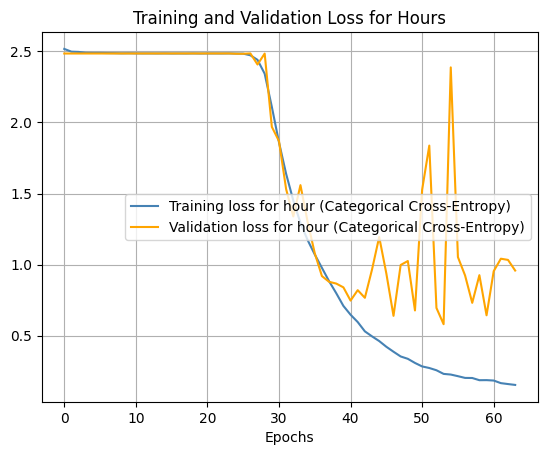

In [ ]:
# Plot hour loss per epoch
plot_loss_accuracy("hour_prediction_loss", "val_hour_prediction_loss", history_two_head_model_14_more_epochs_sigmoid, "Hours")

BEST MODELS!!!!

In [ ]:
input_ = keras.layers.Input(shape = x_75_train.shape[1:])

# COMMON FEATURE EXTRACTION LAYERS

## Hidden layers uses Conv2D so it can learn spatial patterns from the images, code found on pg. 455 of the book

# Start with convolutional layer with kernel of size 5 x 5 as recommended on page 461 of the book
hidden1 = keras.layers.Conv2D(filters = 30, kernel_size = 5, strides = 2, padding = "same", activation="relu")(input_)
hidden1_norm = keras.layers.BatchNormalization()(hidden1)
max_pooling_deep_1 = keras.layers.MaxPooling2D(2)(hidden1_norm)
hidden2 = keras.layers.Conv2D(filters = 75, kernel_size = 3, strides = 1, padding = "same", activation="relu")(max_pooling_deep_1)
hidden2_norm = keras.layers.BatchNormalization()(hidden2)
hidden3 = keras.layers.Conv2D(filters = 150, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden2_norm)
hidden3_norm = keras.layers.BatchNormalization()(hidden3)

# Add one more layer for better learning
hidden4= keras.layers.Conv2D(filters = 300, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden3_norm)
hidden4_norm = keras.layers.BatchNormalization()(hidden4)

# Add another more layer for better learning
hidden5= keras.layers.Conv2D(filters = 360, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden4_norm)
hidden5_norm = keras.layers.BatchNormalization()(hidden5)



# We add a skip layer here in order to feed the outputs through this layer during backpropagation as well

# In order for that to work first the dimensions of hidden2_norm and hidden3_norm need to be the same so we apply the transformation:
hidden2_resized = keras.layers.Conv2D(150, kernel_size=1, strides=1, padding="same")(hidden2_norm)
skip = keras.layers.Add()([hidden2_resized, hidden3_norm])
skip_norm = keras.layers.BatchNormalization()(skip)
skip_act = keras.layers.Activation("relu")(skip_norm) # Add activation also after the skip layer
max_pooling_deep_2 = keras.layers.MaxPooling2D(2)(skip_act)

# Add another skip layer along with the new convolutional layer
hidden3_resized = keras.layers.Conv2D(300, kernel_size=1, strides=1, padding="same")(hidden3_norm)
skip_2 = keras.layers.Add()([hidden3_resized, hidden4_norm])
skip_norm_2 = keras.layers.BatchNormalization()(skip_2)
skip_act_2 = keras.layers.Activation("relu")(skip_norm_2) # Add activation also after the skip layer
max_pooling_deep_3 = keras.layers.MaxPooling2D(2)(skip_act_2)

# Yet another skip layer for the new convolutional layer
hidden4_resized = keras.layers.Conv2D(360, kernel_size=1, strides=1, padding="same")(hidden4_norm)
skip_3 = keras.layers.Add()([hidden4_resized, hidden5_norm])
skip_norm_3 = keras.layers.BatchNormalization()(skip_3)
skip_act_3 = keras.layers.Activation("relu")(skip_norm_3) # Add activation also after the skip layer
max_pooling_deep_4 = keras.layers.MaxPooling2D(2)(skip_act_3)


# Flatten output before passing to the dense layers
flattened = keras.layers.Flatten()(max_pooling_deep_4)

# HOUR RECOGNITION LAYERS
hidden_hours = keras.layers.Dense(60, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(flattened)
hidden_hours = keras.layers.Dropout(0.1)(hidden_hours)
hidden_hours = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_hours)
output_hours = keras.layers.Dense(12, name = "hour_prediction", activation="softmax", kernel_regularizer = keras.regularizers.l2(0.001)) (hidden_hours)

# MINUTE RECOGNITION LAYERS
hidden_minutes = keras.layers.Dense(30, activation= "relu", kernel_regularizer = keras.regularizers.l2(0.001))(flattened)
hidden_minutes_norm = keras.layers.LayerNormalization()(hidden_minutes)
hidden_minutes_2 = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_norm)
hidden_minutes_2_norm = keras.layers.LayerNormalization()(hidden_minutes_2)
output_minutes = keras.layers.Dense(1, name = "minute_prediction", activation="linear", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_2_norm)

two_head_model_14_more_epochs_2 = keras.Model(inputs=input_, outputs=[output_hours, output_minutes])

two_head_model_14_more_epochs_2.compile(loss = {"hour_prediction": "categorical_crossentropy", "minute_prediction": "mse"},
                    optimizer=keras.optimizers.Adam(learning_rate = 0.0001),
                    metrics={"minute_prediction":circular_mae_minutes},
                    loss_weights = {"hour_prediction": 0.9, "minute_prediction": 0.1})

history_two_head_model_14_more_epochs_2 = two_head_model_14_more_epochs_2.fit(x_75_train,
                                            {"hour_prediction": y_75_train_hour,
                                            "minute_prediction":y_75_train_minutes},
                                            epochs=100,
                                            validation_data=(x_75_validation,
                                                            {"hour_prediction": y_75_validation_hour,
                                                            "minute_prediction": y_75_validation_minutes}),
                                            callbacks = [keras.callbacks.EarlyStopping(monitor = "val_loss", patience = 15, restore_best_weights = True)]
                                                )

# Save the model so we can use it even if runtime ends
two_head_model_14_more_epochs_2.save("two_head_model_14_more_epochs_2.keras")

Epoch 1/100
456/456 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - hour_prediction_loss: 2.5657 - loss: 91.5684 - minute_prediction_circular_mae_minutes: 15.0777 - minute_prediction_loss: 890.2834 - val_hour_prediction_loss: 2.4849 - val_loss: 82.9753 - val_minute_prediction_circular_mae_minutes: 14.5918 - val_minute_prediction_loss: 804.1750
Epoch 2/100
456/456 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - hour_prediction_loss: 2.5053 - loss: 84.9899 - minute_prediction_circular_mae_minutes: 15.0922 - minute_prediction_loss: 825.2946 - val_hour_prediction_loss: 2.4849 - val_loss: 76.9656 - val_minute_prediction_circular_mae_minutes: 14.5538 - val_minute_prediction_loss: 744.3791
Epoch 3/100
456/456 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - hour_prediction_loss: 2.5001 - loss: 78.8420 - minute_prediction_circular_mae_minutes: 15.1021 - minute_prediction_loss: 764.0759 - val_hour_prediction_loss: 2.4850 - val_loss: 70.9020 - val_minute_prediction_circular_mae_minutes: 14.5183 - val_minute_prediction_loss: 684.

In [ ]:
# Compute the common sense MAE for the hours
common_sense_mae_hours_mod_14_more_epochs_2 = circular_mae_two_head(two_head_model_14_more_epochs_2, x_75_test, y_75_test)

# Print the output on the minutes scale
error_in_minutes_model_14_more_epochs_2 = common_sense_mae_hours_mod_14_more_epochs_2 * 720
print("Common sense error in minutes for model 14, 100 epochs with higher early stopping patience: ", error_in_minutes_model_14_more_epochs_2)


57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step
Common sense error in minutes for model 14, 100 epochs with higher early stopping patience:  13.245000000000001


In [ ]:
input_ = keras.layers.Input(shape = x_75_train.shape[1:])

# COMMON FEATURE EXTRACTION LAYERS

## Hidden layers uses Conv2D so it can learn spatial patterns from the images, code found on pg. 455 of the book

# Start with convolutional layer with kernel of size 5 x 5 as recommended on page 461 of the book
hidden1 = keras.layers.Conv2D(filters = 30, kernel_size = 5, strides = 2, padding = "same", activation="relu")(input_)
hidden1_norm = keras.layers.BatchNormalization()(hidden1)
max_pooling_deep_1 = keras.layers.MaxPooling2D(2)(hidden1_norm)
hidden2 = keras.layers.Conv2D(filters = 75, kernel_size = 3, strides = 1, padding = "same", activation="relu")(max_pooling_deep_1)
hidden2_norm = keras.layers.BatchNormalization()(hidden2)
hidden3 = keras.layers.Conv2D(filters = 150, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden2_norm)
hidden3_norm = keras.layers.BatchNormalization()(hidden3)

# Add one more layer for better learning
hidden4= keras.layers.Conv2D(filters = 300, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden3_norm)
hidden4_norm = keras.layers.BatchNormalization()(hidden4)

# Add another more layer for better learning
hidden5= keras.layers.Conv2D(filters = 360, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden4_norm)
hidden5_norm = keras.layers.BatchNormalization()(hidden5)



# We add a skip layer here in order to feed the outputs through this layer during backpropagation as well

# In order for that to work first the dimensions of hidden2_norm and hidden3_norm need to be the same so we apply the transformation:
hidden2_resized = keras.layers.Conv2D(150, kernel_size=1, strides=1, padding="same")(hidden2_norm)
skip = keras.layers.Add()([hidden2_resized, hidden3_norm])
skip_norm = keras.layers.BatchNormalization()(skip)
skip_act = keras.layers.Activation("relu")(skip_norm) # Add activation also after the skip layer
max_pooling_deep_2 = keras.layers.MaxPooling2D(2)(skip_act)

# Add another skip layer along with the new convolutional layer
hidden3_resized = keras.layers.Conv2D(300, kernel_size=1, strides=1, padding="same")(hidden3_norm)
skip_2 = keras.layers.Add()([hidden3_resized, hidden4_norm])
skip_norm_2 = keras.layers.BatchNormalization()(skip_2)
skip_act_2 = keras.layers.Activation("relu")(skip_norm_2) # Add activation also after the skip layer
max_pooling_deep_3 = keras.layers.MaxPooling2D(2)(skip_act_2)

# Yet another skip layer for the new convolutional layer
hidden4_resized = keras.layers.Conv2D(360, kernel_size=1, strides=1, padding="same")(hidden4_norm)
skip_3 = keras.layers.Add()([hidden4_resized, hidden5_norm])
skip_norm_3 = keras.layers.BatchNormalization()(skip_3)
skip_act_3 = keras.layers.Activation("relu")(skip_norm_3) # Add activation also after the skip layer
max_pooling_deep_4 = keras.layers.MaxPooling2D(2)(skip_act_3)


# Flatten output before passing to the dense layers
flattened = keras.layers.Flatten()(max_pooling_deep_4)

# HOUR RECOGNITION LAYERS
hidden_hours = keras.layers.Dense(60, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(flattened)
hidden_hours = keras.layers.Dropout(0.1)(hidden_hours)
hidden_hours = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_hours)
output_hours = keras.layers.Dense(12, name = "hour_prediction", activation="softmax", kernel_regularizer = keras.regularizers.l2(0.001)) (hidden_hours)

# MINUTE RECOGNITION LAYERS
hidden_minutes = keras.layers.Dense(30, activation= "relu", kernel_regularizer = keras.regularizers.l2(0.001))(flattened)
hidden_minutes_norm = keras.layers.LayerNormalization()(hidden_minutes)
hidden_minutes_2 = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_norm)
hidden_minutes_2_norm = keras.layers.LayerNormalization()(hidden_minutes_2)
output_minutes = keras.layers.Dense(1, name = "minute_prediction", activation="linear", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_2_norm)

two_head_model_14_more_epochs = keras.Model(inputs=input_, outputs=[output_hours, output_minutes])

two_head_model_14_more_epochs.compile(loss = {"hour_prediction": "categorical_crossentropy", "minute_prediction": "mse"},
                    optimizer=keras.optimizers.Adam(learning_rate = 0.0001),
                    metrics={"minute_prediction":circular_mae_minutes},
                    loss_weights = {"hour_prediction": 0.9, "minute_prediction": 0.1})

history_two_head_model_14_more_epochs = two_head_model_14_more_epochs.fit(x_75_train,
                                            {"hour_prediction": y_75_train_hour,
                                            "minute_prediction":y_75_train_minutes},
                                            epochs=100,
                                            validation_data=(x_75_validation,
                                                            {"hour_prediction": y_75_validation_hour,
                                                            "minute_prediction": y_75_validation_minutes}),
                                            callbacks = [keras.callbacks.EarlyStopping(monitor = "val_loss", patience = 10, restore_best_weights = True)]
                                                )

# Save the model so we can use it even if runtime ends
two_head_model_14_more_epochs.save("two_head_model_14_more_epochs.keras")

Epoch 1/100
456/456 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - hour_prediction_loss: 2.5647 - loss: 91.5675 - minute_prediction_circular_mae_minutes: 15.0777 - minute_prediction_loss: 890.2834 - val_hour_prediction_loss: 2.4849 - val_loss: 82.9697 - val_minute_prediction_circular_mae_minutes: 14.5919 - val_minute_prediction_loss: 804.1188
Epoch 2/100
456/456 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - hour_prediction_loss: 2.5032 - loss: 84.9882 - minute_prediction_circular_mae_minutes: 15.0922 - minute_prediction_loss: 825.2953 - val_hour_prediction_loss: 2.4849 - val_loss: 76.9645 - val_minute_prediction_circular_mae_minutes: 14.5538 - val_minute_prediction_loss: 744.3664
Epoch 3/100
456/456 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - hour_prediction_loss: 2.5006 - loss: 78.8426 - minute_prediction_circular_mae_minutes: 15.1021 - minute_prediction_loss: 764.0756 - val_hour_prediction_loss: 2.4850 - val_loss: 70.9030 - val_minute_prediction_circular_mae_minutes: 14.5183 - val_minute_prediction_loss: 684.

In [6]:
# Compute the common sense MAE for the hours
common_sense_mae_hours_mod_14_more_epochs = circular_mae_two_head(two_head_model_14_more_epochs, x_75_test, y_75_test)

# Print the output on the minutes scale
error_in_minutes_model_14_more_epochs = common_sense_mae_hours_mod_14_more_epochs * 720
print("Common sense error in minutes for model 14, 100 epochs: ", error_in_minutes_model_14_more_epochs)

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step
Common sense error in minutes for model 14, 100 epochs:  10.745555555555555


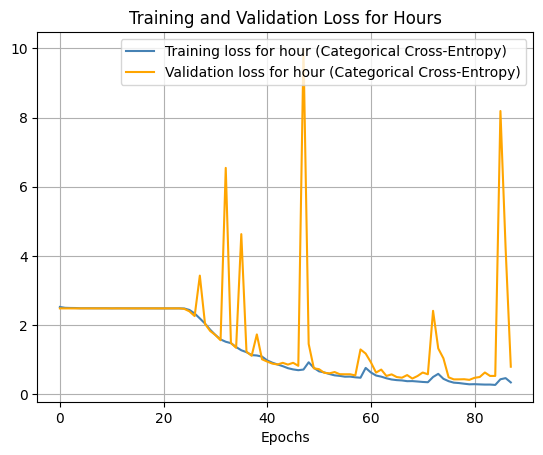

In [7]:
# Plot hour loss per epoch
plot_loss_accuracy("hour_prediction_loss", "val_hour_prediction_loss", history_two_head_model_14_more_epochs, "Hours")

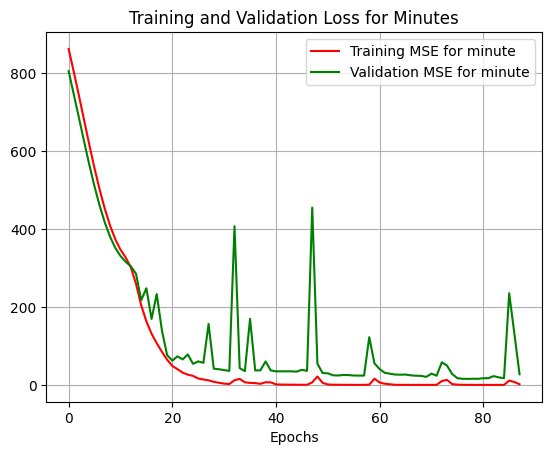

In [8]:
# Plot minute loss per epoch
plot_loss_accuracy("minute_prediction_loss", "val_minute_prediction_loss", history_two_head_model_14_more_epochs, "Minutes")

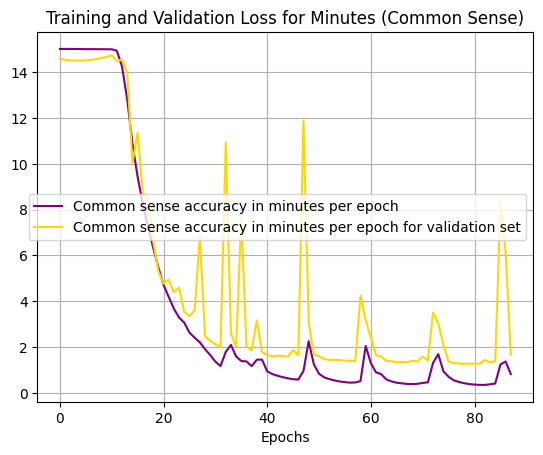

In [9]:
# Plot common sense MAE per epoch (only for minutes)
plot_loss_accuracy("minute_prediction_circular_mae_minutes", "val_minute_prediction_circular_mae_minutes", history_two_head_model_14_more_epochs, "Minutes (Common Sense)")

Run best model on 150 dataset

In [11]:
# Load the small dataset to start training
x_150 = np.load("A1_data_150/images.npy")
y_150 = np.load("A1_data_150/labels.npy")

# Normalise inputs, as in task 1
x_150 = x_150.astype('float32') / 255.0

# Split into training and test set and shuffle and since the datasets are ordered, it is recommended in the assignment spec to shuffle
x_150_train, x_150_test, y_150_train, y_150_test = train_test_split(x_150, y_150, test_size = 0.10, random_state = 2029197, shuffle = True)

# Split again into training-validation sets
x_150_train, x_150_validation, y_150_train, y_150_validation = train_test_split(x_150_train, y_150_train, test_size = 0.10, random_state = 202197)

# Separate minutes and hours in dataset
y_150_train_hour = y_150_train[:,0]
y_150_train_minutes = y_150_train[:,1]

y_150_validation_hour = y_150_validation[:,0]
y_150_validation_minutes = y_150_validation[:,1]

y_150_test_hour = y_150_test[:,0]
y_150_test_minutes = y_150_test[:,1]

# Reshape for Convolutional Layers
x_150_train = x_150_train.reshape(x_150_train.shape[0], 150, 150, 1)
x_150_test = x_150_test.reshape(x_150_test.shape[0], 150, 150, 1)
x_150_validation = x_150_validation.reshape(x_150_validation.shape[0], 150, 150, 1)

# Convert the hour labels to one-hot encoding
y_150_train_hour= tf.keras.utils.to_categorical(y_150_train_hour, num_classes=12)
y_150_validation_hour = tf.keras.utils.to_categorical(y_150_validation_hour, num_classes=12)


In [13]:
input_ = keras.layers.Input(shape = x_150_train.shape[1:])

# COMMON FEATURE EXTRACTION LAYERS

## Hidden layers uses Conv2D so it can learn spatial patterns from the images, code found on pg. 455 of the book

# Start with convolutional layer with kernel of size 5 x 5 as recommended on page 461 of the book
hidden1 = keras.layers.Conv2D(filters = 30, kernel_size = 5, strides = 2, padding = "same", activation="relu")(input_)
hidden1_norm = keras.layers.BatchNormalization()(hidden1)
max_pooling_deep_1 = keras.layers.MaxPooling2D(2)(hidden1_norm)
hidden2 = keras.layers.Conv2D(filters = 75, kernel_size = 3, strides = 1, padding = "same", activation="relu")(max_pooling_deep_1)
hidden2_norm = keras.layers.BatchNormalization()(hidden2)
hidden3 = keras.layers.Conv2D(filters = 150, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden2_norm)
hidden3_norm = keras.layers.BatchNormalization()(hidden3)

# Add one more layer for better learning
hidden4= keras.layers.Conv2D(filters = 300, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden3_norm)
hidden4_norm = keras.layers.BatchNormalization()(hidden4)

# Add another more layer for better learning
hidden5= keras.layers.Conv2D(filters = 360, kernel_size = 2, strides = 1, padding = "same", activation = "relu")(hidden4_norm)
hidden5_norm = keras.layers.BatchNormalization()(hidden5)



# We add a skip layer here in order to feed the outputs through this layer during backpropagation as well

# In order for that to work first the dimensions of hidden2_norm and hidden3_norm need to be the same so we apply the transformation:
hidden2_resized = keras.layers.Conv2D(150, kernel_size=1, strides=1, padding="same")(hidden2_norm)
skip = keras.layers.Add()([hidden2_resized, hidden3_norm])
skip_norm = keras.layers.BatchNormalization()(skip)
skip_act = keras.layers.Activation("relu")(skip_norm) # Add activation also after the skip layer
max_pooling_deep_2 = keras.layers.MaxPooling2D(2)(skip_act)

# Add another skip layer along with the new convolutional layer
hidden3_resized = keras.layers.Conv2D(300, kernel_size=1, strides=1, padding="same")(hidden3_norm)
skip_2 = keras.layers.Add()([hidden3_resized, hidden4_norm])
skip_norm_2 = keras.layers.BatchNormalization()(skip_2)
skip_act_2 = keras.layers.Activation("relu")(skip_norm_2) # Add activation also after the skip layer
max_pooling_deep_3 = keras.layers.MaxPooling2D(2)(skip_act_2)

# Yet another skip layer for the new convolutional layer
hidden4_resized = keras.layers.Conv2D(360, kernel_size=1, strides=1, padding="same")(hidden4_norm)
skip_3 = keras.layers.Add()([hidden4_resized, hidden5_norm])
skip_norm_3 = keras.layers.BatchNormalization()(skip_3)
skip_act_3 = keras.layers.Activation("relu")(skip_norm_3) # Add activation also after the skip layer
max_pooling_deep_4 = keras.layers.MaxPooling2D(2)(skip_act_3)


# Flatten output before passing to the dense layers
flattened = keras.layers.Flatten()(max_pooling_deep_4)

# HOUR RECOGNITION LAYERS
hidden_hours = keras.layers.Dense(60, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(flattened)
hidden_hours = keras.layers.Dropout(0.1)(hidden_hours)
hidden_hours = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_hours)
output_hours = keras.layers.Dense(12, name = "hour_prediction", activation="softmax", kernel_regularizer = keras.regularizers.l2(0.001)) (hidden_hours)

# MINUTE RECOGNITION LAYERS
hidden_minutes = keras.layers.Dense(30, activation= "relu", kernel_regularizer = keras.regularizers.l2(0.001))(flattened)
hidden_minutes_norm = keras.layers.LayerNormalization()(hidden_minutes)
hidden_minutes_2 = keras.layers.Dense(15, activation = "relu", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_norm)
hidden_minutes_2_norm = keras.layers.LayerNormalization()(hidden_minutes_2)
output_minutes = keras.layers.Dense(1, name = "minute_prediction", activation="linear", kernel_regularizer = keras.regularizers.l2(0.001))(hidden_minutes_2_norm)

two_head_model_14_150 = keras.Model(inputs=input_, outputs=[output_hours, output_minutes])

two_head_model_14_150.compile(loss = {"hour_prediction": "categorical_crossentropy", "minute_prediction": "mse"},
                    optimizer=keras.optimizers.Adam(learning_rate = 0.0001),
                    metrics={"minute_prediction":circular_mae_minutes},
                    loss_weights = {"hour_prediction": 0.9, "minute_prediction": 0.1})

history_two_head_model_14_150 = two_head_model_14_150.fit(x_150_train,
                                            {"hour_prediction": y_150_train_hour,
                                            "minute_prediction":y_150_train_minutes},
                                            epochs=50,
                                            validation_data=(x_150_validation,
                                                            {"hour_prediction": y_150_validation_hour,
                                                            "minute_prediction": y_150_validation_minutes}),
                                            callbacks = [keras.callbacks.EarlyStopping(monitor = "val_loss", patience = 10, restore_best_weights = True)]
                                                )

# Save the model so we can use it even if runtime ends
two_head_model_14_150.save("two_head_model_14_150.keras")

Epoch 1/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 80s 133ms/step - hour_prediction_loss: 2.7853 - loss: 96.2274 - minute_prediction_circular_mae_minutes: 15.0722 - minute_prediction_loss: 934.9120 - val_hour_prediction_loss: 2.4851 - val_loss: 86.7553 - val_minute_prediction_circular_mae_minutes: 14.6243 - val_minute_prediction_loss: 841.9819
Epoch 2/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 43s 95ms/step - hour_prediction_loss: 2.5408 - loss: 89.1166 - minute_prediction_circular_mae_minutes: 15.0853 - minute_prediction_loss: 866.3066 - val_hour_prediction_loss: 2.4851 - val_loss: 80.8206 - val_minute_prediction_circular_mae_minutes: 14.5760 - val_minute_prediction_loss: 782.9561
Epoch 3/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 43s 94ms/step - hour_prediction_loss: 2.5136 - loss: 82.8327 - minute_prediction_circular_mae_minutes: 15.0955 - minute_prediction_loss: 803.9454 - val_hour_prediction_loss: 2.4852 - val_loss: 74.5843 - val_minute_prediction_circular_mae_minutes: 14.5380 - val_minute_prediction_loss: 720.87

In [14]:
# Compute the common sense MAE for the hours
common_sense_mae_two_head_model_14_150 = circular_mae_two_head(two_head_model_14_150, x_150_test, y_150_test)

# Print the output on the minutes scale
error_in_minutes_model_14_150 = common_sense_mae_two_head_model_14_150 * 720
print("Common sense error in minutes for model 14, 150 set: ", error_in_minutes_model_14_150)

57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step
Common sense error in minutes for model 14, 150 set:  29.551111111111105
